# Learning Curve Analysis: Experiment 2

**Objective**: Analyze how method performance degrades as the number of training rows decreases.

---

## Overview

**Experiment 2** evaluates performance degradation across varying training set sizes:
1. Tests methods at multiple row limits (e.g., 50k, 40k, ..., 1k rows)
2. Uses **NO HPO** (default parameters only) to isolate the effect of data size
3. Identifies which methods are most robust to limited training data
4. Helps select methods appropriate for small vs. large datasets

This notebook provides:
- **Learning Curve Plots**: Performance vs. training set size
- **Degradation Analysis**: How much performance drops as data decreases
- **Robustness Rankings**: Which methods maintain performance with less data

---

## 1. Setup & Configuration

In [1]:
# Standard imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pickle

# =============================================================================
# SETUP PATHS (Notebook is in notebooks/ folder)
# =============================================================================

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent  # notebooks/ -> project root
sys.path.insert(0, str(PROJECT_ROOT))

EXPERIMENT_NAME = "experiment2"
RESULTS_DIR = PROJECT_ROOT / "results" / EXPERIMENT_NAME
SUMMARY_DIR = RESULTS_DIR / "summary"
FIGURES_DIR = RESULTS_DIR / "figures"

# Load config to get expected row limits
from src.utils.config_reader import load_config

print("=" * 80)
print("  EXPERIMENT 2 POST-ANALYSIS: LEARNING CURVE ANALYSIS")
print("=" * 80)
print(f"Project root:       {PROJECT_ROOT}")
print(f"Results directory:  {RESULTS_DIR}")
print(f"Summary directory:  {SUMMARY_DIR}")
print(f"Figures directory:  {FIGURES_DIR}")

# =============================================================================
# LOAD CONFIG AND CHECK COMPLETENESS
# =============================================================================

try:
    config = load_config("Experiment2")
    lc_config = config.get("learning_curve", {})
    row_max = lc_config.get("row_max", 50000)
    row_min = lc_config.get("row_min", 1000)
    row_step = lc_config.get("row_step", 5000)
    
    # Generate expected row limits
    expected_row_limits = []
    current = row_max
    while current >= row_min:
        expected_row_limits.append(current)
        current -= row_step
    if expected_row_limits[-1] != row_min:
        expected_row_limits.append(row_min)
    
    print(f"\nExpected row limits from config: {expected_row_limits}")
    print(f"  row_max={row_max}, row_min={row_min}, row_step={row_step}")
    
    # Get expected datasets and methods
    pd_datasets = list(config.get("datasets", {}).get("pd", {}).keys())
    lgd_datasets = list(config.get("datasets", {}).get("lgd", {}).keys())
    pd_methods = list(config.get("methods", {}).get("pd", {}).keys())
    lgd_methods = list(config.get("methods", {}).get("lgd", {}).keys())
    
    print(f"\nExpected PD datasets: {len(pd_datasets)}")
    print(f"Expected PD methods: {len(pd_methods)}")
    print(f"Expected LGD datasets: {len(lgd_datasets)}")
    print(f"Expected LGD methods: {len(lgd_methods)}")
    
except Exception as e:
    print(f"\n[WARNING] Could not load config: {e}")
    expected_row_limits = None
    pd_datasets, lgd_datasets = [], []
    pd_methods, lgd_methods = [], []

# =============================================================================
# CHECK RESULT COMPLETENESS
# =============================================================================
# 
# Result file structure for Experiment2:
#   - Results stored as: {results_dir}/{task_type}/{dataset}.pkl
#   - Each .pkl contains: results[row_limit][method] = fold_results
#   - This mirrors Experiment1's structure with row_limit replacing hpo_mode
#
# =============================================================================

def check_result_completeness(results_dir: Path, task_type: str, expected_datasets: list, 
                               expected_methods: list, expected_row_limits: list):
    """
    Check which dataset-method-row_limit combinations are missing results.
    
    Reads each {dataset}.pkl file and checks the nested structure:
        results[row_limit][method] = fold_results
    
    Returns:
        missing_results: dict mapping "dataset|method" -> list of missing row_limits
        complete_count: number of complete dataset-method-row_limit combinations
        total_expected: total number of expected combinations
    """
    results_subdir = results_dir / task_type
    
    if not results_subdir.exists():
        print(f"[WARNING] Results directory not found: {results_subdir}")
        return {}, 0, len(expected_datasets) * len(expected_methods) * len(expected_row_limits)
    
    missing_results = {}
    complete_count = 0
    total_expected = len(expected_datasets) * len(expected_methods) * len(expected_row_limits)
    
    for dataset in expected_datasets:
        # Result file is {dataset}.pkl (NOT {dataset}_{method}_row{limit}.pkl)
        result_file = results_subdir / f"{dataset}.pkl"
        
        # Load existing results for this dataset
        dataset_results = {}
        if result_file.exists():
            try:
                with open(result_file, 'rb') as f:
                    dataset_results = pickle.load(f)
            except Exception as e:
                print(f"[WARNING] Could not load {result_file.name}: {e}")
        
        # Check each method
        for method in expected_methods:
            missing_row_limits = []
            
            for row_limit in expected_row_limits:
                # Check if results[row_limit][method] exists
                if row_limit in dataset_results and method in dataset_results.get(row_limit, {}):
                    complete_count += 1
                else:
                    missing_row_limits.append(row_limit)
            
            if missing_row_limits:
                key = f"{dataset}|{method}"
                missing_results[key] = missing_row_limits
    
    return missing_results, complete_count, total_expected


print("\n" + "=" * 80)
print("  RESULT COMPLETENESS CHECK")
print("=" * 80)

if expected_row_limits and pd_datasets and pd_methods:
    pd_missing, pd_complete, pd_total = check_result_completeness(
        RESULTS_DIR, "pd", pd_datasets, pd_methods, expected_row_limits
    )
    
    pct_complete = 100*pd_complete/pd_total if pd_total > 0 else 0
    print(f"\nPD Task Completeness: {pd_complete}/{pd_total} ({pct_complete:.1f}%)")
    
    if pd_missing:
        print(f"\n[MISSING PD RESULTS] {len(pd_missing)} dataset-method combinations incomplete:")
        for key, missing_limits in sorted(pd_missing.items())[:20]:  # Show first 20
            dataset, method = key.split("|")
            print(f"  {dataset} | {method}: missing row_limits = {missing_limits}")
        if len(pd_missing) > 20:
            print(f"  ... and {len(pd_missing) - 20} more")
    else:
        print("  All PD results complete!")

if expected_row_limits and lgd_datasets and lgd_methods:
    lgd_missing, lgd_complete, lgd_total = check_result_completeness(
        RESULTS_DIR, "lgd", lgd_datasets, lgd_methods, expected_row_limits
    )
    
    pct_complete = 100*lgd_complete/lgd_total if lgd_total > 0 else 0
    print(f"\nLGD Task Completeness: {lgd_complete}/{lgd_total} ({pct_complete:.1f}%)")
    
    if lgd_missing:
        print(f"\n[MISSING LGD RESULTS] {len(lgd_missing)} dataset-method combinations incomplete:")
        for key, missing_limits in sorted(lgd_missing.items())[:20]:
            dataset, method = key.split("|")
            print(f"  {dataset} | {method}: missing row_limits = {missing_limits}")
        if len(lgd_missing) > 20:
            print(f"  ... and {len(lgd_missing) - 20} more")
    else:
        print("  All LGD results complete!")

# =============================================================================
# GENERATE SUMMARIES IF NOT ALREADY PRESENT
# =============================================================================

# Check if summary folder exists and has files
if SUMMARY_DIR.exists() and any(SUMMARY_DIR.glob("*.csv")):
    print(f"\n Summary files already exist. Skipping generation.")
    print(f"   (Delete {SUMMARY_DIR} manually to regenerate)")
else:
    print(f"\n Summary files not found. Generating summaries...")
    
    # Import and run summarize_results
    from src.utils.summarize_results import summarize_results
    
    print("\n" + "=" * 80)
    summarize_results(experiment=EXPERIMENT_NAME)
    print("=" * 80)

# Ensure figures directory exists
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("\n Setup complete! Ready for analysis.")
print("=" * 80)

  EXPERIMENT 2 POST-ANALYSIS: LEARNING CURVE ANALYSIS
Project root:       c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit
Results directory:  c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment2
Summary directory:  c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment2\summary
Figures directory:  c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment2\figures

Expected row limits from config: [15000, 14900, 14800, 14700, 14600, 14500, 14400, 14300, 14200, 14100, 14000, 13900, 13800, 13700, 13600, 13500, 13400, 13300, 13200, 13100, 13000, 12900, 12800, 12700, 12600, 12500, 12400, 12300, 12200, 12100, 12000, 11900, 11800, 11700, 11600, 11500, 11400, 11300, 11200, 11100, 11000, 10900, 10800, 10700, 10600, 10500, 10400, 10300, 10200, 10100, 10000, 9900, 9800, 9700, 9600, 9500, 9400, 9300, 9200, 9100, 9000

In [2]:
# Plotting configuration
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')

# Color schemes
CMAP_PERFORMANCE = 'RdYlGn'       # Red (bad) to Green (good)
CMAP_DEGRADATION = 'RdYlGn_r'     # Green (low degradation) to Red (high)
CMAP_TIME = 'YlOrRd'              # Yellow (fast) to Red (slow)

# Use a distinct color palette for learning curves
N_COLORS = 20
LEARNING_CURVE_PALETTE = sns.color_palette('husl', n_colors=N_COLORS)

## 2. Data Loading

In [3]:
# Load raw and aggregated results
try:
    pd_raw = pd.read_csv(SUMMARY_DIR / "summary_pd_raw.csv")
    pd_agg = pd.read_csv(SUMMARY_DIR / "summary_pd_aggregated.csv")
    has_pd = True
except FileNotFoundError:
    print("Warning: PD results not found")
    pd_raw = pd.DataFrame()
    pd_agg = pd.DataFrame()
    has_pd = False

try:
    lgd_raw = pd.read_csv(SUMMARY_DIR / "summary_lgd_raw.csv")
    lgd_agg = pd.read_csv(SUMMARY_DIR / "summary_lgd_aggregated.csv")
    has_lgd = True
except FileNotFoundError:
    print("Warning: LGD results not found")
    lgd_raw = pd.DataFrame()
    lgd_agg = pd.DataFrame()
    has_lgd = False

print("\n Data Overview:")

if has_pd and not pd_raw.empty:
    row_limits_pd = sorted(pd_raw['row_limit'].unique(), reverse=True)
    print(f"\nPD (Probability of Default):")
    print(f"  - Raw results: {len(pd_raw)} fold results")
    print(f"  - Methods: {pd_raw['method'].nunique()}")
    print(f"  - Datasets: {pd_raw['dataset'].nunique()}")
    print(f"  - Row limits: {len(row_limits_pd)} ({max(row_limits_pd):,} -> {min(row_limits_pd):,})")
    print(f"  - Methods: {sorted(pd_raw['method'].unique())}")

if has_lgd and not lgd_raw.empty:
    row_limits_lgd = sorted(lgd_raw['row_limit'].unique(), reverse=True)
    print(f"\nLGD (Loss Given Default):")
    print(f"  - Raw results: {len(lgd_raw)} fold results")
    print(f"  - Methods: {lgd_raw['method'].nunique()}")
    print(f"  - Datasets: {lgd_raw['dataset'].nunique()}")
    print(f"  - Row limits: {len(row_limits_lgd)} ({max(row_limits_lgd):,} -> {min(row_limits_lgd):,})")
    print(f"  - Methods: {sorted(lgd_raw['method'].unique())}")


 Data Overview:

PD (Probability of Default):
  - Raw results: 36535 fold results
  - Methods: 5
  - Datasets: 11
  - Row limits: 151 (15,000 -> 100)
  - Methods: ['LogReg', 'catboost', 'ftt', 'lightgbm', 'xgboost']

LGD (Loss Given Default):
  - Raw results: 8950 fold results
  - Methods: 6
  - Datasets: 2
  - Row limits: 150 (15,000 -> 100)
  - Methods: ['LinearRegression', 'autoint', 'catboost', 'lightgbm', 'modernNCA', 'xgboost']


In [4]:
# Display sample of raw data
if has_pd and not pd_raw.empty:
    print("\nSample PD Raw Data (first 10 rows):")
    display(pd_raw.head(10))
    
    print("\nPD Aggregated Data columns:")
    print(pd_agg.columns.tolist())


Sample PD Raw Data (first 10 rows):


,method,dataset,task,hpo_mode,fold_id,Optimal_Threshold,AUC,Gini,Avg_Precision,KS,...,F1,Precision,Recall,MCC,train_time,n_clipped_below,n_clipped_above,n_num_features,n_cat_features,row_limit
0,LogReg,0001.gmsc,pd,NO_HPO,1,0.168384,0.849600,0.699200,0.337360,0.549286,...,0.415350,0.378601,0.460000,0.371257,0.007509,0.0,0.0,10,0,15000
1,LogReg,0001.gmsc,pd,NO_HPO,2,0.158485,0.827664,0.655329,0.371278,0.519286,...,0.443914,0.424658,0.465000,0.402736,0.006930,0.0,0.0,10,0,15000
2,LogReg,0001.gmsc,pd,NO_HPO,3,0.158485,0.813997,0.627994,0.291140,0.504727,...,0.372506,0.336000,0.417910,0.324398,0.006843,0.0,0.0,10,0,15000
3,LogReg,0001.gmsc,pd,NO_HPO,4,0.168384,0.838224,0.676448,0.354933,0.516437,...,0.405594,0.381579,0.432836,0.360846,0.007040,0.0,0.0,10,0,15000
4,LogReg,0001.gmsc,pd,NO_HPO,5,0.138687,0.833119,0.666238,0.380271,0.502584,...,0.398422,0.330065,0.502488,0.354607,0.007245,0.0,0.0,10,0,15000
5,catboost,0001.gmsc,pd,NO_HPO,1,0.198081,0.860254,0.720507,0.379073,0.574643,...,0.421286,0.378486,0.475000,0.377729,20.517545,0.0,0.0,10,0,15000
6,catboost,0001.gmsc,pd,NO_HPO,2,0.148586,0.840964,0.681929,0.390987,0.551429,...,0.427966,0.371324,0.505000,0.385656,19.546516,0.0,0.0,10,0,15000
7,catboost,0001.gmsc,pd,NO_HPO,3,0.257475,0.831377,0.662754,0.333938,0.528318,...,0.413098,0.418367,0.407960,0.371554,20.993064,0.0,0.0,10,0,15000
8,catboost,0001.gmsc,pd,NO_HPO,4,0.188182,0.870617,0.741233,0.406328,0.609973,...,0.443418,0.413793,0.477612,0.401563,18.615402,0.0,0.0,10,0,15000
9,catboost,0001.gmsc,pd,NO_HPO,5,0.217879,0.844943,0.689886,0.391046,0.534754,...,0.416465,0.405660,0.427861,0.373515,21.496684,0.0,0.0,10,0,15000



PD Aggregated Data columns:
['method', 'dataset', 'row_limit', 'task', 'n_folds', 'AUC_mean', 'AUC_std', 'AUC_min', 'AUC_max', 'Accuracy_mean', 'Accuracy_std', 'Accuracy_min', 'Accuracy_max', 'Avg_Precision_mean', 'Avg_Precision_std', 'Avg_Precision_min', 'Avg_Precision_max', 'Balanced_Accuracy_mean', 'Balanced_Accuracy_std', 'Balanced_Accuracy_min', 'Balanced_Accuracy_max', 'Brier_mean', 'Brier_std', 'Brier_min', 'Brier_max', 'F1_mean', 'F1_std', 'F1_min', 'F1_max', 'Gini_mean', 'Gini_std', 'Gini_min', 'Gini_max', 'KS_mean', 'KS_std', 'KS_min', 'KS_max', 'LogLoss_mean', 'LogLoss_std', 'LogLoss_min', 'LogLoss_max', 'MCC_mean', 'MCC_std', 'MCC_min', 'MCC_max', 'Precision_mean', 'Precision_std', 'Precision_min', 'Precision_max', 'Recall_mean', 'Recall_std', 'Recall_min', 'Recall_max', 'row_limit_mean', 'row_limit_std', 'row_limit_min', 'row_limit_max', 'train_time_mean', 'train_time_std', 'train_time_min', 'train_time_max', 'n_clipped_below_mean', 'n_clipped_below_std', 'n_clipped_below

## 3. Helper Functions

In [5]:
def plot_learning_curves(
    df: pd.DataFrame,
    metric: str,
    task_name: str,
    methods: list = None,
    dataset: str = None,
    figsize: tuple = (14, 8),
    show_std: bool = True
):
    """
    Plot learning curves showing performance vs. row limit.
    
    Args:
        df: Aggregated dataframe with row_limit column
        metric: Metric to plot (e.g., 'AUC', 'R2')
        task_name: 'PD' or 'LGD'
        methods: List of specific methods to plot. If None, plots all available methods.
        dataset: Optional specific dataset to plot
        figsize: Figure size
        show_std: Whether to show standard deviation bands
    """
    mean_col = f'{metric}_mean'
    std_col = f'{metric}_std'
    
    if mean_col not in df.columns:
        print(f"Warning: Metric '{metric}' not found in data")
        return None
    
    # Filter by dataset if specified
    plot_df = df.copy()
    if dataset is not None:
        plot_df = plot_df[plot_df['dataset'] == dataset]
        title_suffix = f" - {dataset}"
    else:
        # Average across all datasets
        plot_df = plot_df.groupby(['method', 'row_limit']).agg({
            mean_col: 'mean',
            std_col: 'mean'
        }).reset_index()
        title_suffix = " (Averaged Across Datasets)"
    
    # Determine which methods to plot
    if methods is not None:
        # Use specified methods (filter to those actually in data)
        available_methods = plot_df['method'].unique()
        methods_to_plot = [m for m in methods if m in available_methods]
        if not methods_to_plot:
            print(f"Warning: None of the specified methods found in data")
            return None
    else:
        # Plot all available methods
        methods_to_plot = sorted(plot_df['method'].unique())
    
    # Filter to selected methods
    plot_df = plot_df[plot_df['method'].isin(methods_to_plot)]
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot each method
    colors = sns.color_palette('husl', n_colors=len(methods_to_plot))
    
    for i, method in enumerate(methods_to_plot):
        method_df = plot_df[plot_df['method'] == method].sort_values('row_limit')
        
        x = method_df['row_limit'].values
        y = method_df[mean_col].values
        
        # Plot line
        ax.plot(x, y, 'o-', label=method, color=colors[i], linewidth=2, markersize=6)
        
        # Add std band if available and requested
        if show_std and std_col in method_df.columns:
            y_std = method_df[std_col].values
            ax.fill_between(x, y - y_std, y + y_std, color=colors[i], alpha=0.15)
    
    ax.set_xlabel('Number of Training Rows', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_title(f'{task_name} Learning Curves: {metric}{title_suffix}',
                 fontsize=14, fontweight='bold', pad=15)
    
    # Format x-axis with thousands separator
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    
    # Legend outside plot
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save figure
    ds_suffix = f"_{dataset.replace('.', '_')}" if dataset else ""
    filename = FIGURES_DIR / f"{task_name.lower()}_learning_curve_{metric.lower()}{ds_suffix}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved: {filename.name}")
    
    return fig

In [6]:
# Define Foundation and Baseline methods for focused comparison
FOUNDATION_METHODS = {'tabpfn', 'tabpfn_v2', 'tabpfn_real', 'mitra', 'tabicl', 'tabptm'}
BASELINE_METHODS = {'LogReg', 'xgboost', 'LinearRegression'}
FOCUS_METHODS = FOUNDATION_METHODS | BASELINE_METHODS

def plot_learning_curves_foundation_focus(
    df: pd.DataFrame,
    metric: str,
    task_name: str,
    dataset: str = None,
    figsize: tuple = (14, 8),
    show_std: bool = True
):
    """
    Plot learning curves for FOUNDATION MODELS + BASELINES only.
    
    This provides a focused comparison between:
    - Foundation models (TabPFN variants, Mitra, TabICL, TabPTM)
    - Traditional baselines (LogReg/LinearRegression, XGBoost)
    """
    mean_col = f'{metric}_mean'
    std_col = f'{metric}_std'
    
    if mean_col not in df.columns:
        print(f"Warning: Metric '{metric}' not found in data")
        return None
    
    # Filter by dataset if specified
    plot_df = df.copy()
    if dataset is not None:
        plot_df = plot_df[plot_df['dataset'] == dataset]
        title_suffix = f" - {dataset}"
    else:
        # Average across all datasets
        plot_df = plot_df.groupby(['method', 'row_limit']).agg({
            mean_col: 'mean',
            std_col: 'mean'
        }).reset_index()
        title_suffix = " (Averaged Across Datasets)"
    
    # Filter to Foundation + Baseline methods only
    available_focus = [m for m in FOCUS_METHODS if m in plot_df['method'].unique()]
    plot_df = plot_df[plot_df['method'].isin(available_focus)]
    
    if plot_df.empty:
        print(f"No Foundation/Baseline methods found in data")
        return None
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Use distinct colors: blue shades for Foundation, red/orange for Baselines
    foundation_colors = sns.color_palette('Blues_d', n_colors=len(FOUNDATION_METHODS))
    baseline_colors = ['#d62728', '#ff7f0e', '#2ca02c']  # Red, Orange, Green
    
    color_map = {}
    f_idx, b_idx = 0, 0
    for method in available_focus:
        if method in FOUNDATION_METHODS:
            color_map[method] = foundation_colors[f_idx % len(foundation_colors)]
            f_idx += 1
        else:
            color_map[method] = baseline_colors[b_idx % len(baseline_colors)]
            b_idx += 1
    
    for method in available_focus:
        method_df = plot_df[plot_df['method'] == method].sort_values('row_limit')
        if method_df.empty:
            continue
            
        x = method_df['row_limit'].values
        y = method_df[mean_col].values
        
        # Different line styles for foundation vs baseline
        linestyle = '-' if method in FOUNDATION_METHODS else '--'
        marker = 'o' if method in FOUNDATION_METHODS else 's'
        linewidth = 2.5 if method in FOUNDATION_METHODS else 2
        
        ax.plot(x, y, marker=marker, linestyle=linestyle, label=method, 
                color=color_map[method], linewidth=linewidth, markersize=7)
        
        if show_std and std_col in method_df.columns:
            y_std = method_df[std_col].values
            ax.fill_between(x, y - y_std, y + y_std, color=color_map[method], alpha=0.15)
    
    ax.set_xlabel('Number of Training Rows', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_title(f'{task_name} Learning Curves: Foundation Models vs Baselines ({metric}){title_suffix}',
                 fontsize=14, fontweight='bold', pad=15)
    
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save figure
    ds_suffix = f"_{dataset.replace('.', '_')}" if dataset else ""
    filename = FIGURES_DIR / f"{task_name.lower()}_learning_curve_foundation_{metric.lower()}{ds_suffix}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved: {filename.name}")
    
    return fig

In [7]:
# Heatmap functions removed - focusing on learning curve visualizations
# to show how performance degrades with decreasing training data

In [8]:
def calculate_degradation(
    df: pd.DataFrame,
    metric: str,
    task_name: str
) -> pd.DataFrame:
    """
    Calculate performance degradation as training data decreases.
    
    Metrics computed:
    - perf_max: Performance at maximum row limit
    - perf_min: Performance at minimum row limit
    - abs_drop: Absolute drop in performance
    - pct_drop: Percentage drop in performance
    - degradation_rate: Average drop per 1000 rows removed
    
    Args:
        df: Aggregated dataframe
        metric: Metric to analyze
        task_name: 'PD' or 'LGD'
    
    Returns:
        DataFrame with degradation metrics per method
    """
    mean_col = f'{metric}_mean'
    
    if mean_col not in df.columns:
        print(f"Warning: Metric '{metric}' not found")
        return pd.DataFrame()
    
    # Average across datasets first
    avg_df = df.groupby(['method', 'row_limit'])[mean_col].mean().reset_index()
    
    results = []
    
    for method in avg_df['method'].unique():
        method_df = avg_df[avg_df['method'] == method].sort_values('row_limit')
        
        row_max = method_df['row_limit'].max()
        row_min = method_df['row_limit'].min()
        
        perf_max = method_df[method_df['row_limit'] == row_max][mean_col].values[0]
        perf_min = method_df[method_df['row_limit'] == row_min][mean_col].values[0]
        
        abs_drop = perf_max - perf_min
        pct_drop = (abs_drop / perf_max * 100) if perf_max != 0 else 0
        
        # Degradation rate: performance drop per 1000 rows removed
        rows_removed = row_max - row_min
        degradation_rate = (abs_drop / (rows_removed / 1000)) if rows_removed > 0 else 0
        
        results.append({
            'method': method,
            f'{metric}_at_max': perf_max,
            f'{metric}_at_min': perf_min,
            'row_max': row_max,
            'row_min': row_min,
            'abs_drop': abs_drop,
            'pct_drop': pct_drop,
            'degradation_rate_per_1k': degradation_rate
        })
    
    result_df = pd.DataFrame(results)
    
    # Sort by performance at max (best first)
    result_df = result_df.sort_values(f'{metric}_at_max', ascending=False)
    
    return result_df

In [9]:
def plot_degradation_analysis(
    degradation_df: pd.DataFrame,
    metric: str,
    task_name: str,
    figsize: tuple = (16, 6)
):
    """
    Create visualization of performance degradation.
    
    Shows:
    - Performance at max vs min row limit
    - Percentage drop
    - Degradation rate
    """
    if degradation_df.empty:
        return None
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # Sort by performance at max for consistent ordering
    df = degradation_df.sort_values(f'{metric}_at_max', ascending=False)
    methods = df['method'].values
    
    # Plot 1: Performance at max vs min (legend at bottom)
    ax1 = axes[0]
    x = np.arange(len(methods))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, df[f'{metric}_at_max'], width, label=f'Max Rows ({int(df["row_max"].iloc[0]):,})', color='forestgreen', alpha=0.8)
    bars2 = ax1.bar(x + width/2, df[f'{metric}_at_min'], width, label=f'Min Rows ({int(df["row_min"].iloc[0]):,})', color='indianred', alpha=0.8)
    
    ax1.set_xticks(x)
    ax1.set_xticklabels(methods, rotation=45, ha='right')
    ax1.set_ylabel(metric, fontweight='bold')
    ax1.set_title(f'{metric} at Max vs Min Row Limit', fontweight='bold')
    # Move legend to bottom to avoid interference with plot
    ax1.legend(loc='lower right', fontsize=9)
    ax1.grid(axis='y', alpha=0.3)
    
    # Plot 2: Percentage drop (no threshold lines)
    ax2 = axes[1]
    colors = ['forestgreen' if x < 5 else 'gold' if x < 15 else 'indianred' for x in df['pct_drop']]
    bars = ax2.bar(x, df['pct_drop'], color=colors, alpha=0.8, edgecolor='black')
    
    ax2.set_xticks(x)
    ax2.set_xticklabels(methods, rotation=45, ha='right')
    ax2.set_ylabel('Performance Drop (%)', fontweight='bold')
    ax2.set_title('Percentage Drop (Max -> Min Rows)', fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(df['pct_drop']):
        ax2.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
    
    # Plot 3: Degradation rate
    ax3 = axes[2]
    df_sorted = df.sort_values('degradation_rate_per_1k', ascending=True)
    colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(df_sorted)))
    
    ax3.barh(df_sorted['method'], df_sorted['degradation_rate_per_1k'], color=colors, alpha=0.8, edgecolor='black')
    ax3.set_xlabel(f'{metric} Drop per 1K Rows Removed', fontweight='bold')
    ax3.set_title('Degradation Rate (Lower = More Robust)', fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
    
    plt.suptitle(f'{task_name} Performance Degradation Analysis', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save figure
    filename = FIGURES_DIR / f"{task_name.lower()}_degradation_{metric.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved: {filename.name}")
    
    return fig

In [10]:
def plot_robustness_ranking(
    df: pd.DataFrame,
    metric: str,
    task_name: str,
    figsize: tuple = (12, 8)
):
    """
    Create a scatter plot showing performance vs robustness.
    
    X-axis: Performance at max row limit (higher = better)
    Y-axis: Performance drop percentage (lower = more robust)
    
    Best methods are in the bottom-right quadrant.
    """
    degradation_df = calculate_degradation(df, metric, task_name)
    
    if degradation_df.empty:
        return None
    
    fig, ax = plt.subplots(figsize=figsize)
    
    x = degradation_df[f'{metric}_at_max']
    y = degradation_df['pct_drop']
    methods = degradation_df['method']
    
    # Create scatter plot
    scatter = ax.scatter(x, y, s=100, c=range(len(methods)), cmap='viridis', alpha=0.7, edgecolors='black')
    
    # Add method labels
    for i, method in enumerate(methods):
        ax.annotate(method, (x.iloc[i], y.iloc[i]), 
                   xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    # Add quadrant lines
    ax.axhline(y=y.median(), color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=x.median(), color='gray', linestyle='--', alpha=0.5)
    
    # Add quadrant labels
    ax.text(x.max(), y.min(), 'BEST\n(High Perf, Low Drop)', ha='right', va='bottom', 
            fontsize=10, color='green', fontweight='bold', alpha=0.7)
    ax.text(x.min(), y.max(), 'WORST\n(Low Perf, High Drop)', ha='left', va='top',
            fontsize=10, color='red', fontweight='bold', alpha=0.7)
    
    ax.set_xlabel(f'{metric} at Maximum Row Limit', fontsize=12, fontweight='bold')
    ax.set_ylabel('Performance Drop (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'{task_name} Robustness vs Performance',
                 fontsize=14, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    filename = FIGURES_DIR / f"{task_name.lower()}_robustness_scatter_{metric.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved: {filename.name}")
    
    return fig

In [11]:
def plot_relative_performance(
    df: pd.DataFrame,
    metric: str,
    task_name: str,
    methods: list = None,
    figsize: tuple = (14, 8)
):
    """
    Plot relative performance (normalized to performance at MAXIMUM row limit).
    
    This shows how much each method's performance drops relative to its
    performance at the highest row limit (not necessarily its best performance).
    A value of 1.0 means same as at max row limit, 0.9 means 10% drop.
    
    Args:
        df: Aggregated dataframe
        metric: Metric to analyze
        task_name: 'PD' or 'LGD'
        methods: List of specific methods to plot. If None, plots all methods.
        figsize: Figure size
    """
    mean_col = f'{metric}_mean'
    
    if mean_col not in df.columns:
        return None
    
    # Average across datasets
    avg_df = df.groupby(['method', 'row_limit'])[mean_col].mean().reset_index()
    
    # Get max row limit in data
    max_row_limit = avg_df['row_limit'].max()
    
    # Calculate relative performance for each method
    relative_data = []
    
    for method in avg_df['method'].unique():
        method_df = avg_df[avg_df['method'] == method].sort_values('row_limit', ascending=False)
        
        # Get performance at MAXIMUM row limit (not best performance)
        perf_at_max = method_df[method_df['row_limit'] == max_row_limit][mean_col]
        if len(perf_at_max) == 0:
            # Method doesn't have data at max row limit, use its highest available
            perf_at_max = method_df[mean_col].iloc[0]
        else:
            perf_at_max = perf_at_max.values[0]
        
        for _, row in method_df.iterrows():
            relative_perf = row[mean_col] / perf_at_max if perf_at_max != 0 else 0
            relative_data.append({
                'method': method,
                'row_limit': row['row_limit'],
                'relative_perf': relative_perf
            })
    
    rel_df = pd.DataFrame(relative_data)
    
    # Determine which methods to plot
    if methods is not None:
        methods_to_plot = [m for m in methods if m in rel_df['method'].unique()]
    else:
        methods_to_plot = sorted(rel_df['method'].unique())
    
    rel_df = rel_df[rel_df['method'].isin(methods_to_plot)]
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    colors = sns.color_palette('husl', n_colors=len(methods_to_plot))
    
    for i, method in enumerate(methods_to_plot):
        method_df = rel_df[rel_df['method'] == method].sort_values('row_limit')
        ax.plot(method_df['row_limit'], method_df['relative_perf'], 
               'o-', label=method, color=colors[i], linewidth=2, markersize=6)
    
    ax.set_xlabel('Number of Training Rows', fontsize=12, fontweight='bold')
    ax.set_ylabel('Relative Performance (1.0 = Performance at Max Rows)', fontsize=12, fontweight='bold')
    ax.set_title(f'{task_name} Relative Performance Decay',
                 fontsize=14, fontweight='bold', pad=15)
    
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.7, 1.05)
    
    plt.tight_layout()
    
    filename = FIGURES_DIR / f"{task_name.lower()}_relative_performance_{metric.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved: {filename.name}")
    
    return fig

---

# Part A: PD (Probability of Default) Analysis

---

## A1. Learning Curve Visualizations

### A1.1 Overall Learning Curves (AUC)

Creating PD AUC Learning Curves...
Saved: pd_learning_curve_auc.png


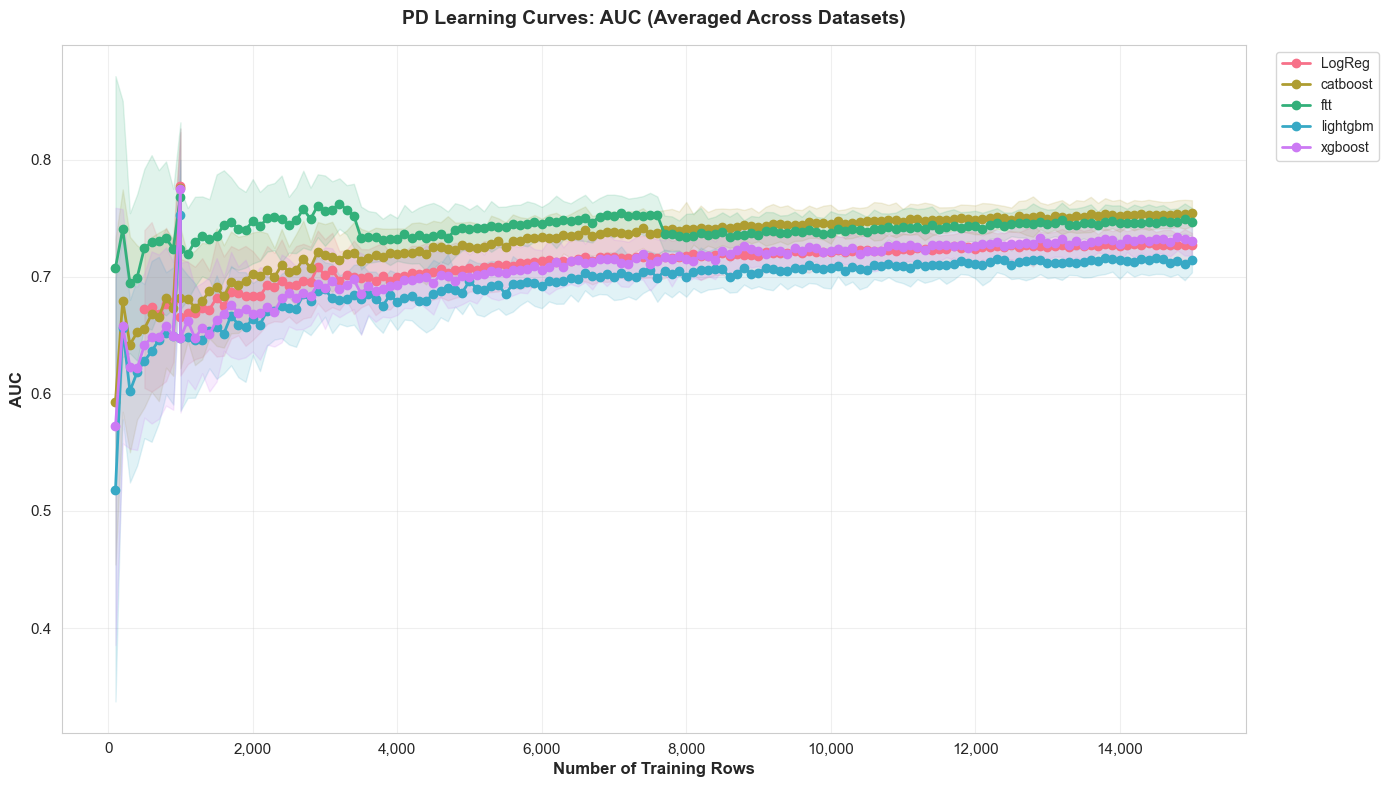

In [12]:
if has_pd and not pd_agg.empty:
    print("Creating PD AUC Learning Curves...")
    plot_learning_curves(pd_agg, 'AUC', 'PD')
    plt.show()
else:
    print("No PD data available")

### A1.2 Overall Learning Curves (F1)

Creating PD F1 Learning Curves...
Saved: pd_learning_curve_f1.png


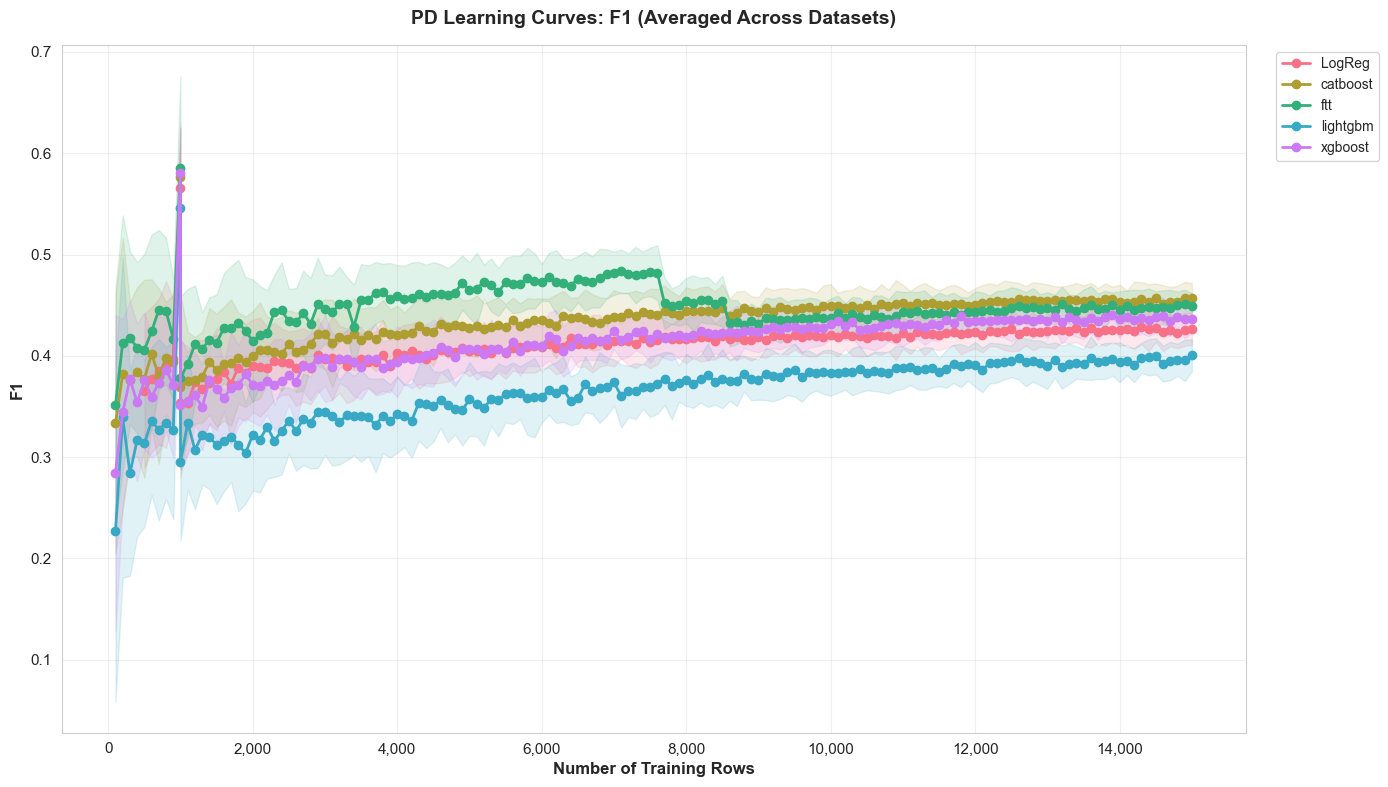

In [13]:
if has_pd and not pd_agg.empty:
    print("Creating PD F1 Learning Curves...")
    plot_learning_curves(pd_agg, 'F1', 'PD')
    plt.show()

### A1.3 Relative Performance Decay

Creating PD Relative Performance Decay...
Saved: pd_relative_performance_auc.png


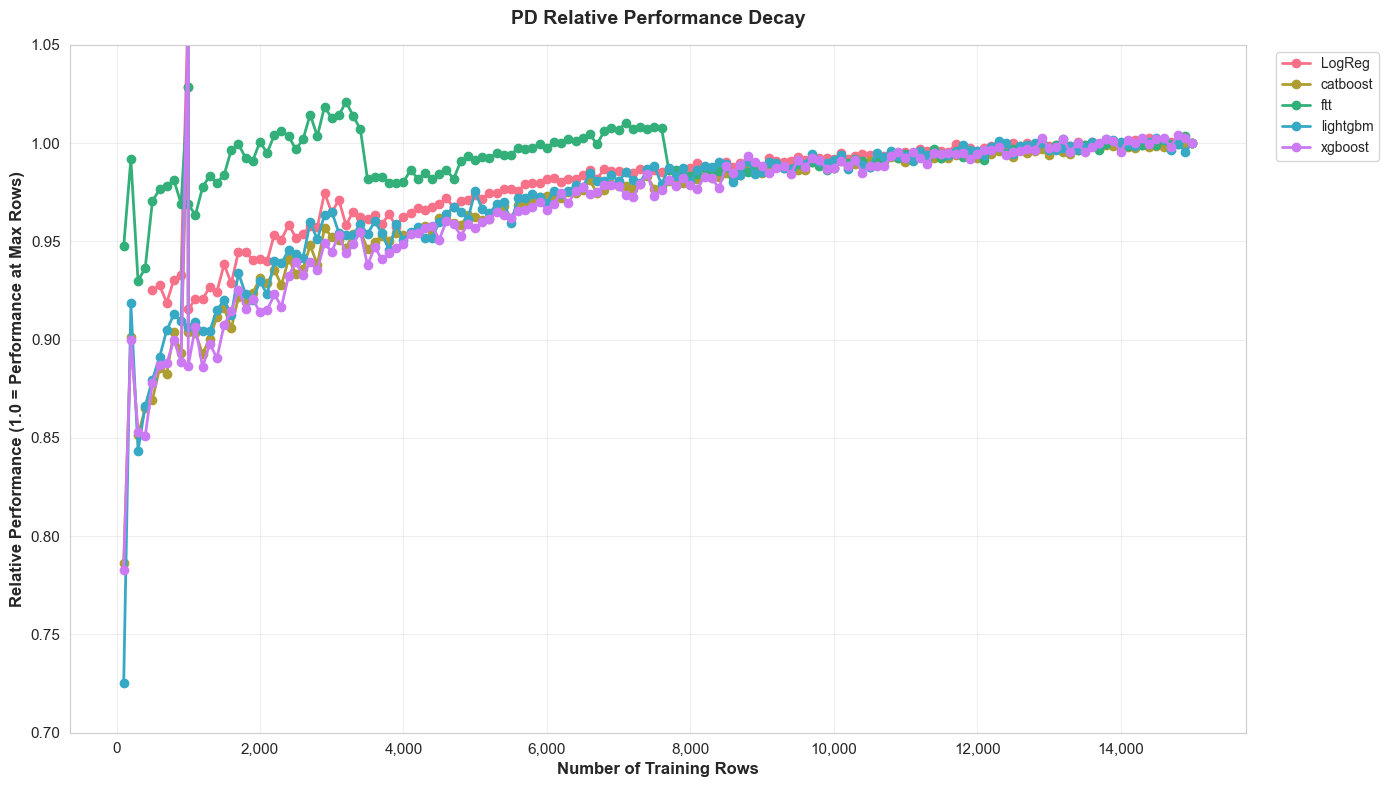

In [14]:
if has_pd and not pd_agg.empty:
    print("Creating PD Relative Performance Decay...")
    plot_relative_performance(pd_agg, 'AUC', 'PD')
    plt.show()

In [15]:
if has_pd and not pd_agg.empty:
    pd_degradation = calculate_degradation(pd_agg, 'AUC', 'PD')
    
    print("\n" + "=" * 80)
    print("  PD DEGRADATION ANALYSIS (AUC)")
    print("=" * 80)
    print("\nMethods sorted by performance at maximum row limit:")
    display(pd_degradation.round(4))
    
    print("\n" + "-" * 40)
    print("Most ROBUST methods (lowest % drop):")
    print("-" * 40)
    print(pd_degradation.nsmallest(5, 'pct_drop')[['method', 'AUC_at_max', 'AUC_at_min', 'pct_drop']].to_string(index=False))
    
    print("\n" + "-" * 40)
    print("LEAST robust methods (highest % drop):")
    print("-" * 40)
    print(pd_degradation.nlargest(5, 'pct_drop')[['method', 'AUC_at_max', 'AUC_at_min', 'pct_drop']].to_string(index=False))


  PD DEGRADATION ANALYSIS (AUC)

Methods sorted by performance at maximum row limit:


,method,AUC_at_max,AUC_at_min,row_max,row_min,abs_drop,pct_drop,degradation_rate_per_1k
1,catboost,0.7543,0.5933,15000,100,0.1610,21.3435,0.0108
2,ftt,0.7469,0.7076,15000,100,0.0393,5.2560,0.0026
4,xgboost,0.7308,0.5722,15000,100,0.1586,21.6999,0.0106
0,LogReg,0.7269,0.6724,15000,500,0.0544,7.4906,0.0038
3,lightgbm,0.7141,0.5178,15000,100,0.1963,27.4921,0.0132



----------------------------------------
Most ROBUST methods (lowest % drop):
----------------------------------------
  method  AUC_at_max  AUC_at_min  pct_drop
     ftt    0.746873    0.707617  5.256001
  LogReg    0.726884    0.672436  7.490566
catboost    0.754279    0.593290 21.343521
 xgboost    0.730804    0.572220 21.699909
lightgbm    0.714061    0.517751 27.492143

----------------------------------------
LEAST robust methods (highest % drop):
----------------------------------------
  method  AUC_at_max  AUC_at_min  pct_drop
lightgbm    0.714061    0.517751 27.492143
 xgboost    0.730804    0.572220 21.699909
catboost    0.754279    0.593290 21.343521
  LogReg    0.726884    0.672436  7.490566
     ftt    0.746873    0.707617  5.256001


### A2.2 Degradation Visualization

Creating PD Degradation Analysis Plots...
Saved: pd_degradation_auc.png


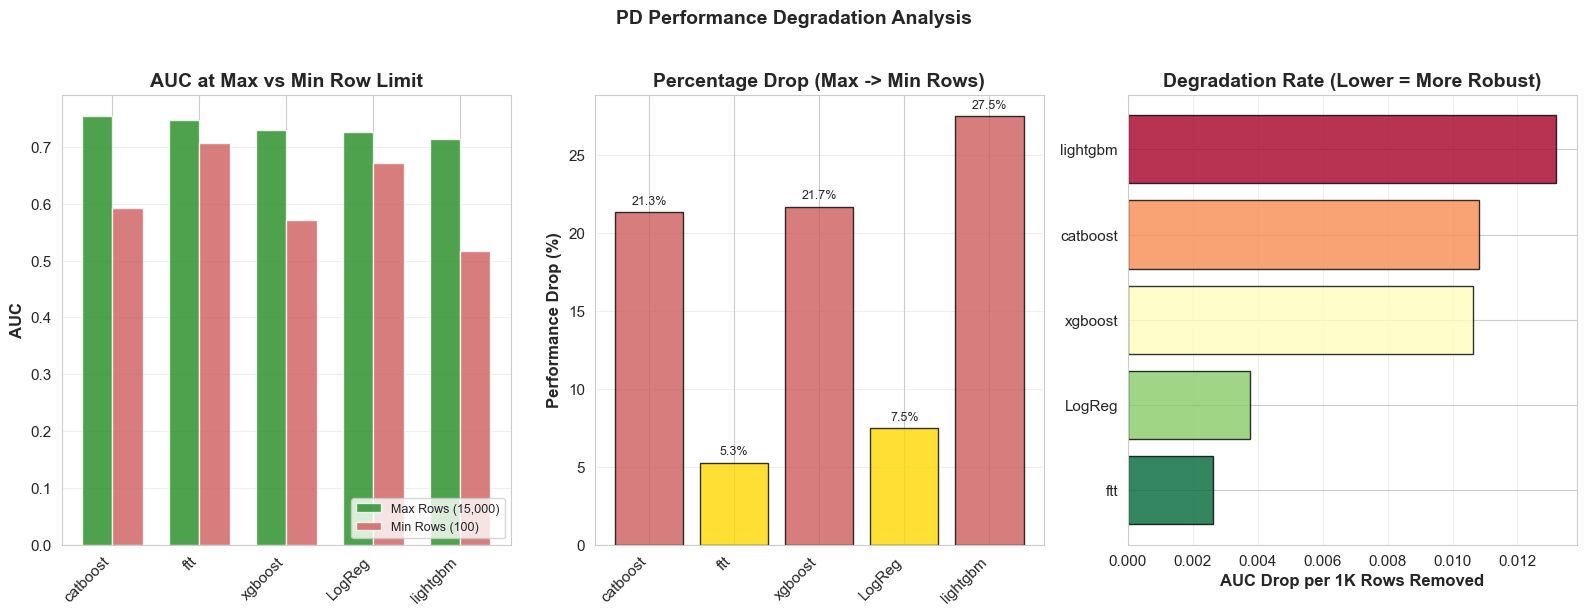

In [16]:
if has_pd and not pd_agg.empty:
    print("Creating PD Degradation Analysis Plots...")
    plot_degradation_analysis(pd_degradation, 'AUC', 'PD')
    plt.show()

### A2.3 Robustness vs Performance Scatter

Creating PD Robustness vs Performance Scatter...
Saved: pd_robustness_scatter_auc.png


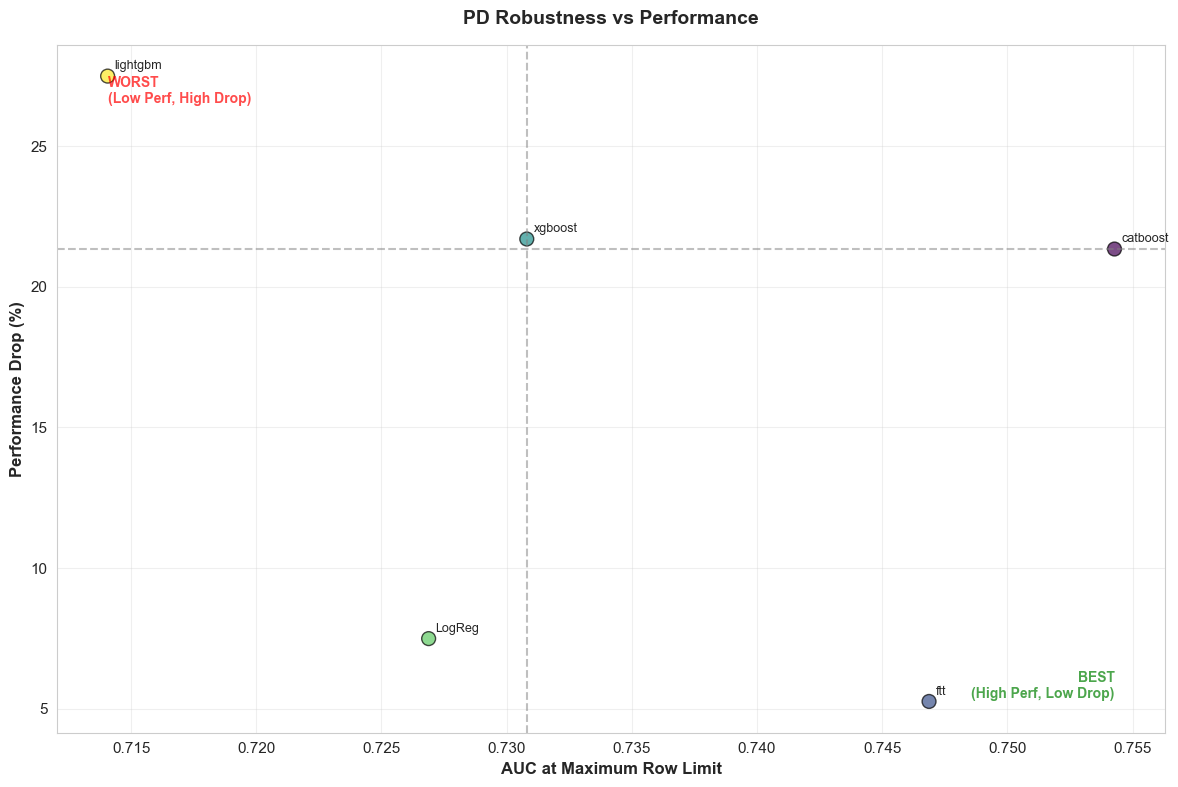

In [17]:
if has_pd and not pd_agg.empty:
    print("Creating PD Robustness vs Performance Scatter...")
    plot_robustness_ranking(pd_agg, 'AUC', 'PD')
    plt.show()

## A3. Per-Dataset Analysis


  FOUNDATION MODELS vs BASELINES (Averaged Across Datasets)
Saved: pd_learning_curve_foundation_auc.png


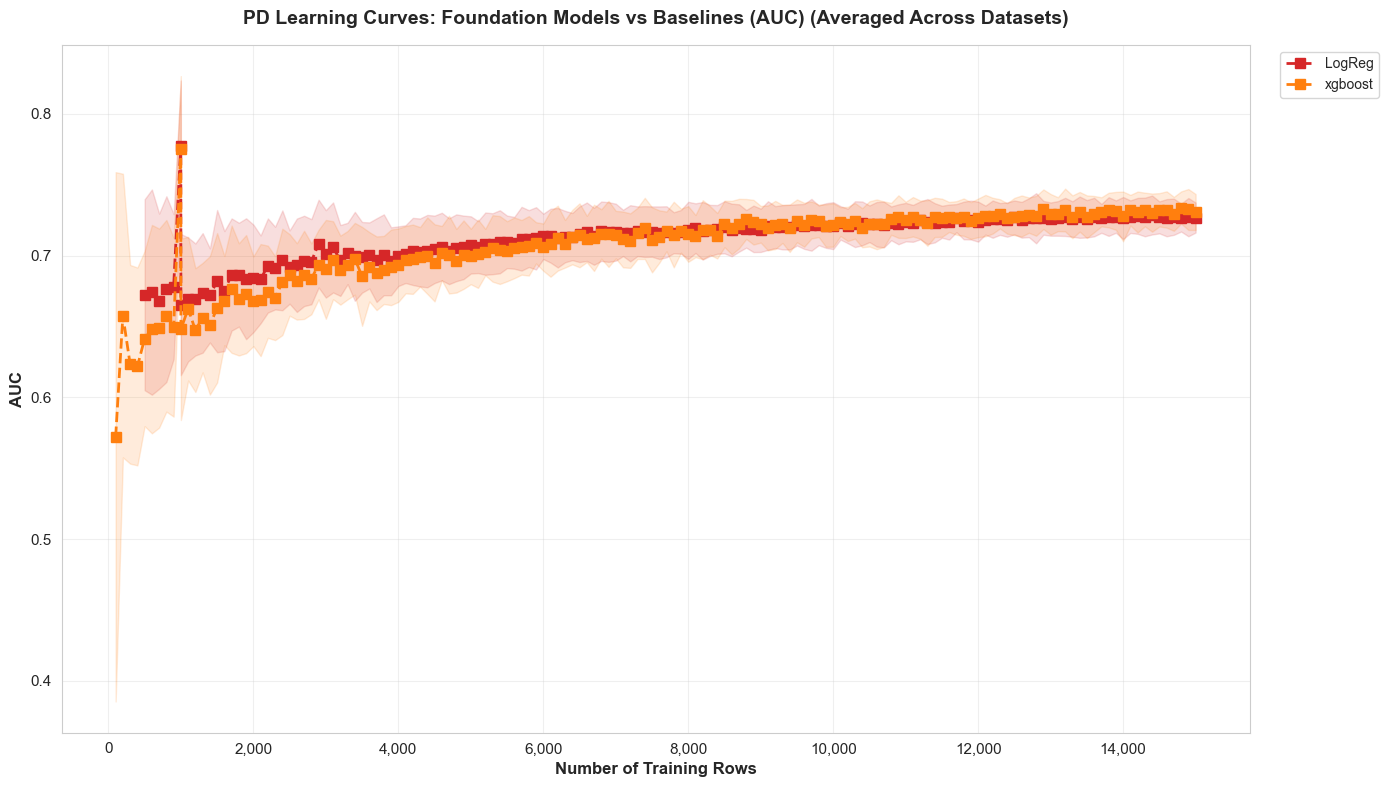


  PER-DATASET LEARNING CURVES

Generating learning curves for 11 datasets...

Dataset: 0001.gmsc
Saved: pd_learning_curve_auc_0001_gmsc.png


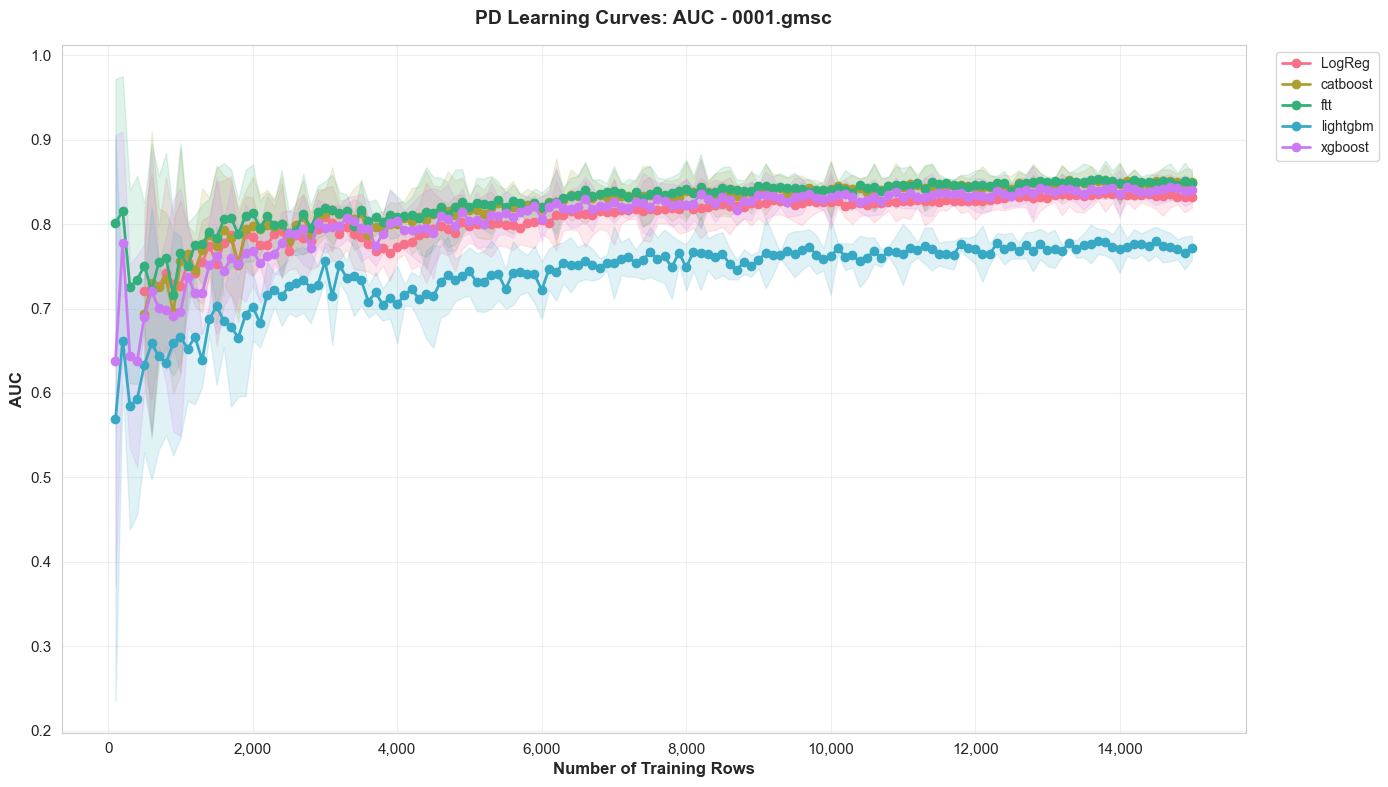

Saved: pd_learning_curve_foundation_auc_0001_gmsc.png


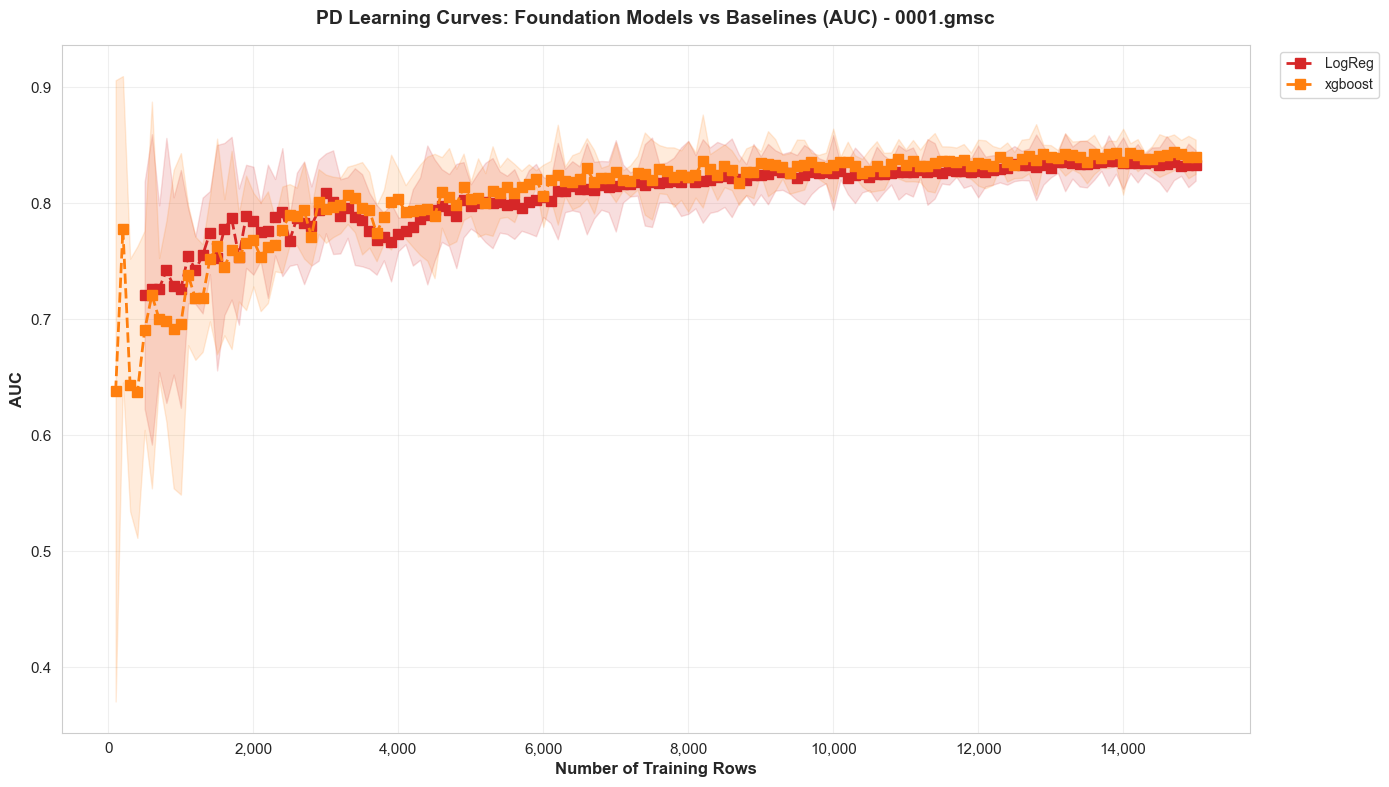


Dataset: 0002.taiwan_creditcard
Saved: pd_learning_curve_auc_0002_taiwan_creditcard.png


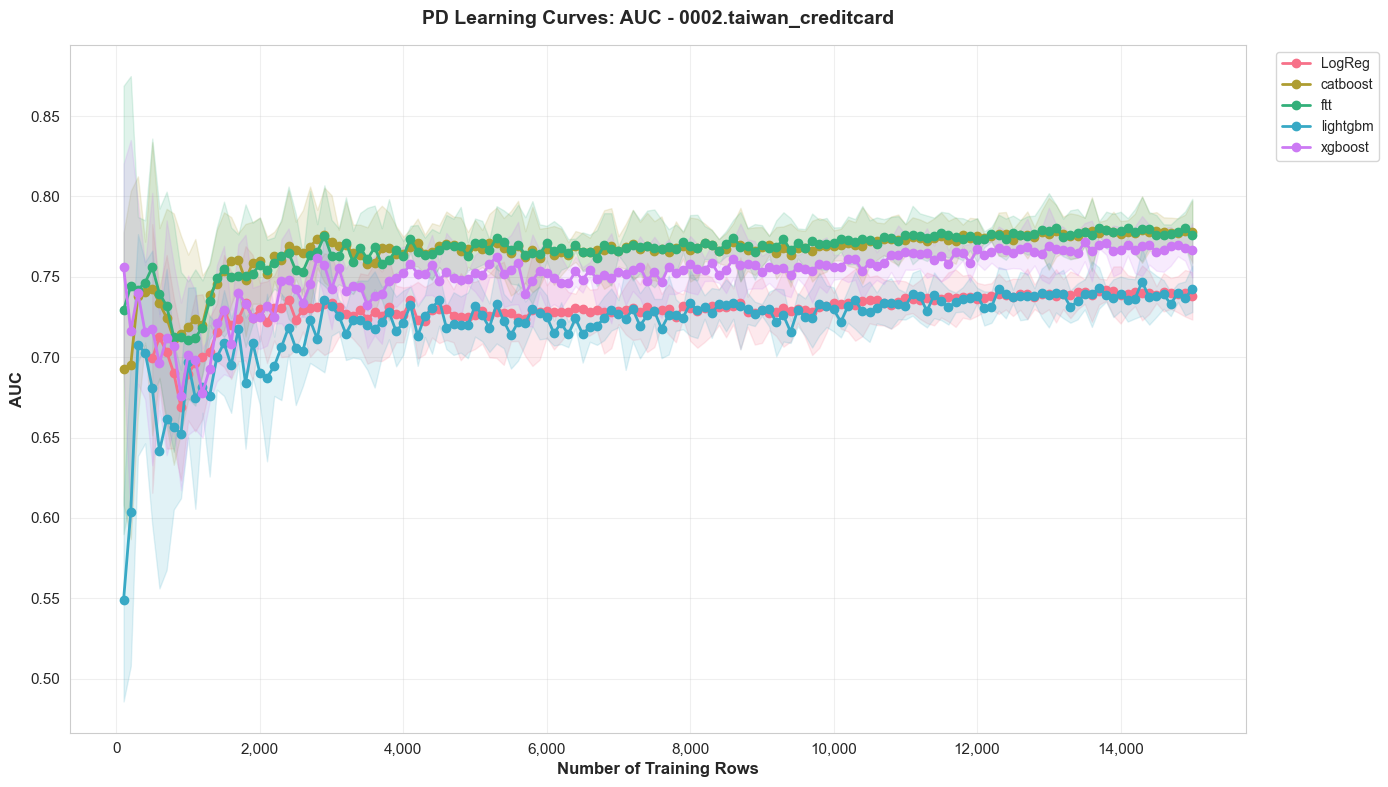

Saved: pd_learning_curve_foundation_auc_0002_taiwan_creditcard.png


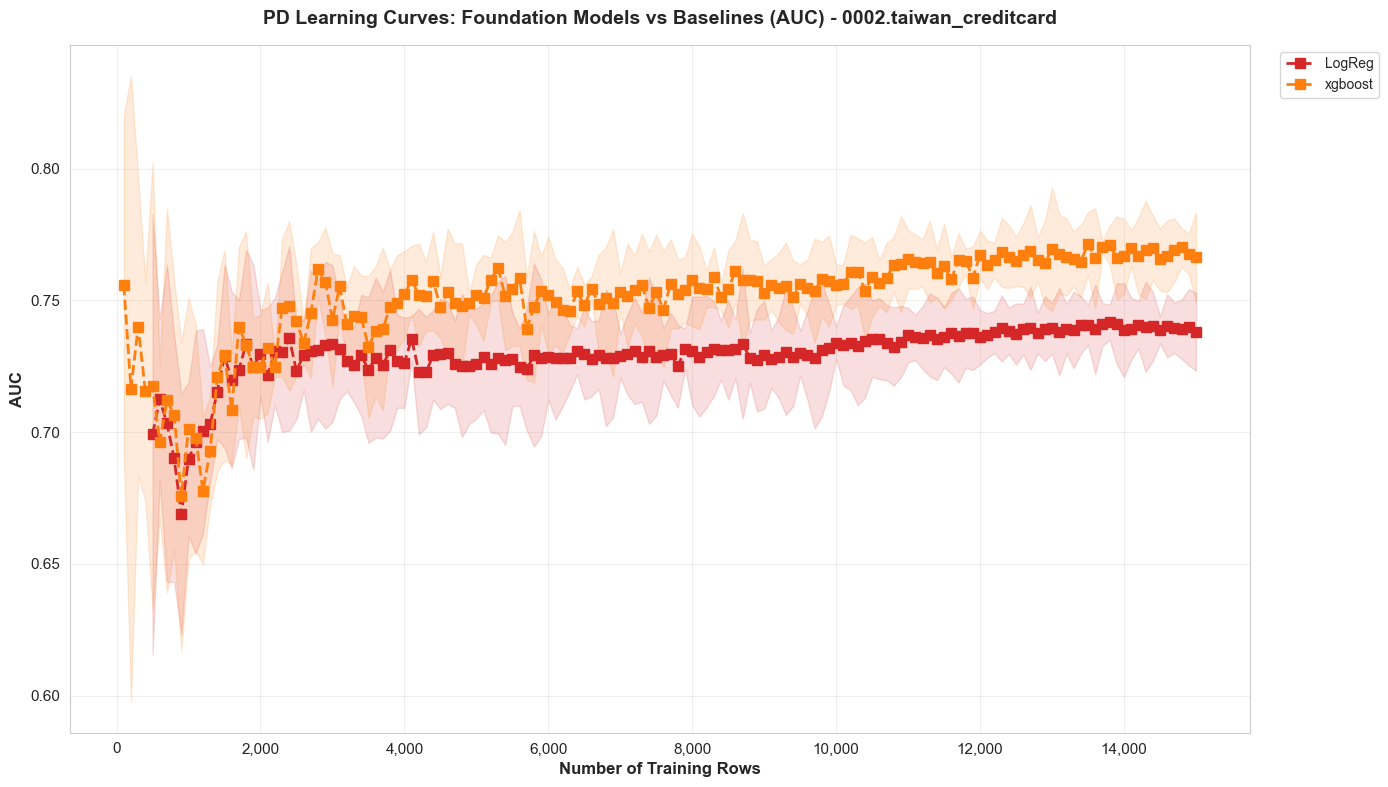


Dataset: 0003.vehicle_loan
Saved: pd_learning_curve_auc_0003_vehicle_loan.png


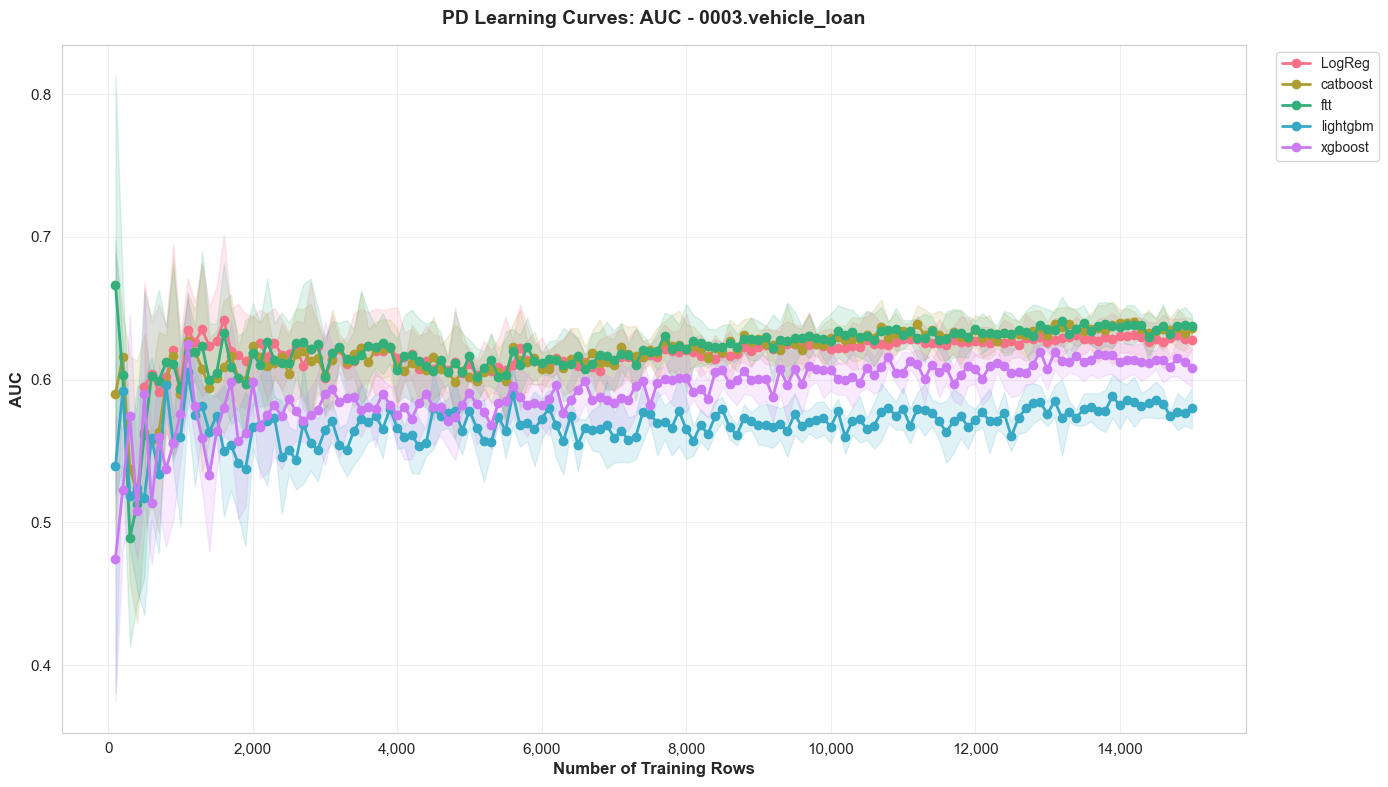

Saved: pd_learning_curve_foundation_auc_0003_vehicle_loan.png


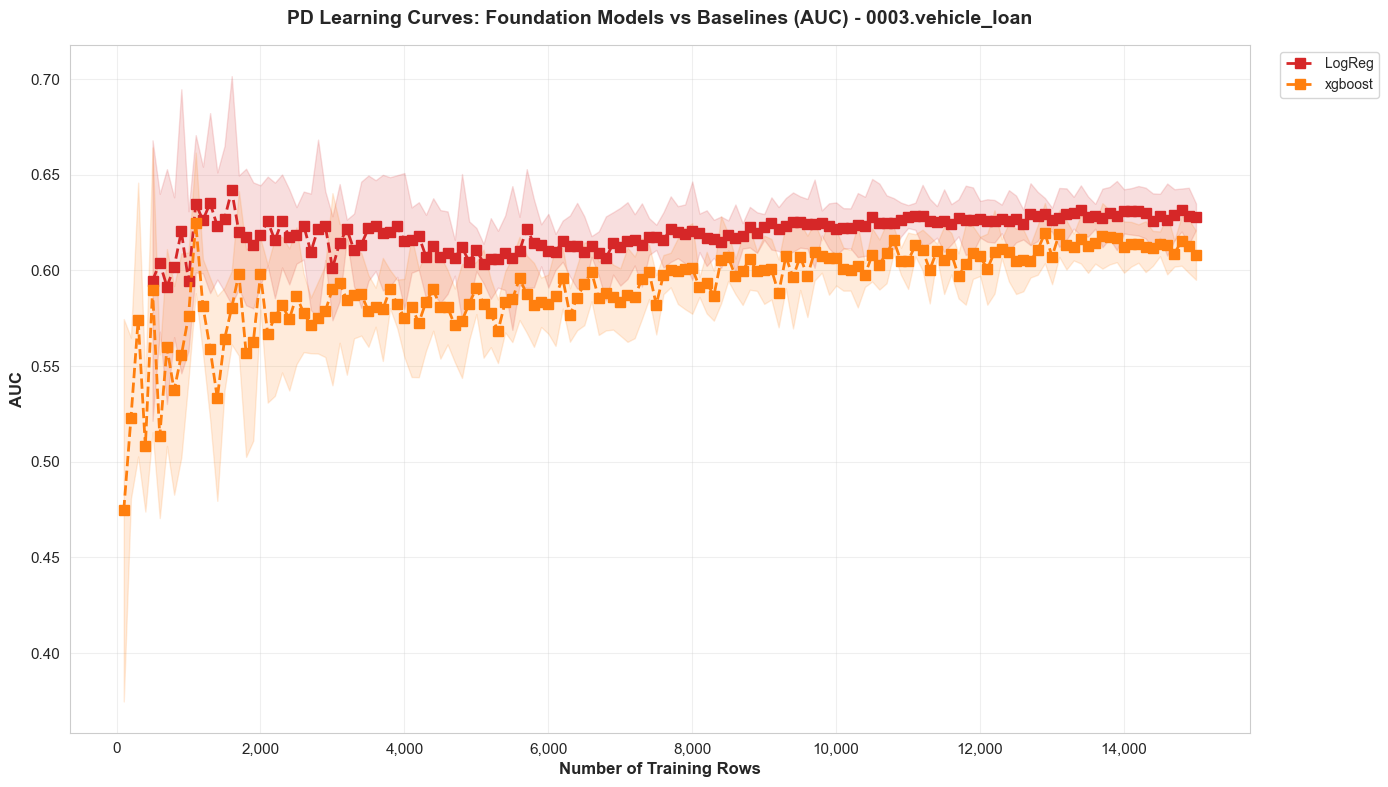


Dataset: 0005.case_study
Saved: pd_learning_curve_auc_0005_case_study.png


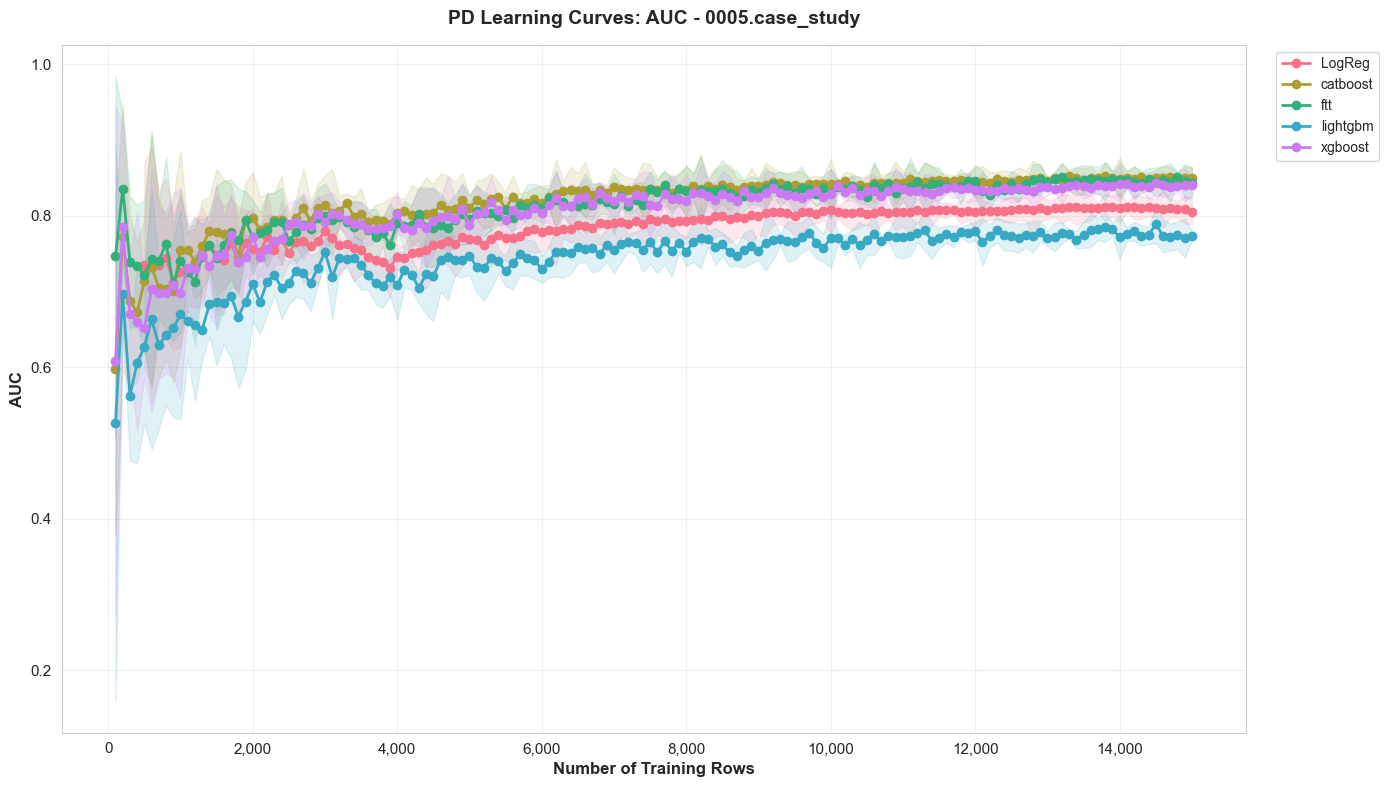

Saved: pd_learning_curve_foundation_auc_0005_case_study.png


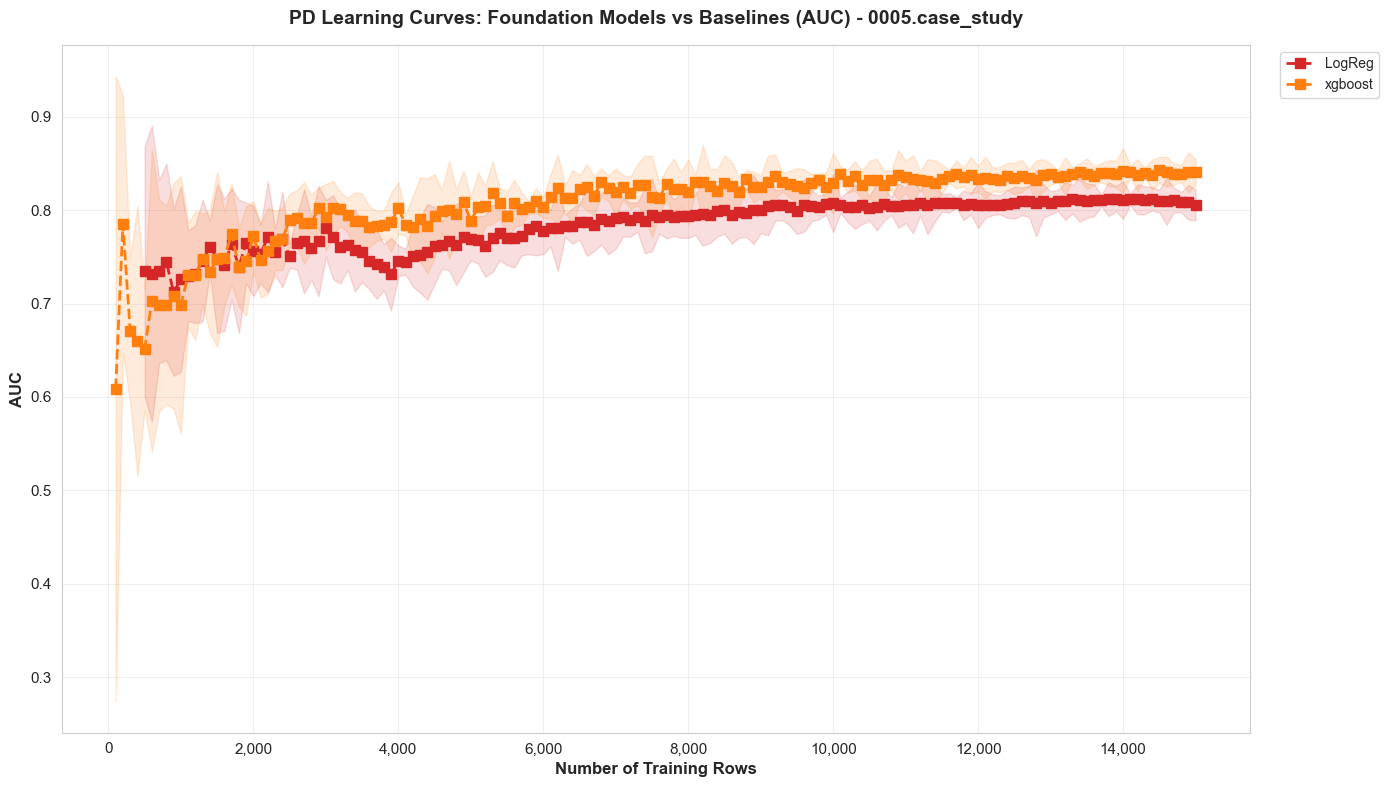


Dataset: 0007.hackerearth
Saved: pd_learning_curve_auc_0007_hackerearth.png


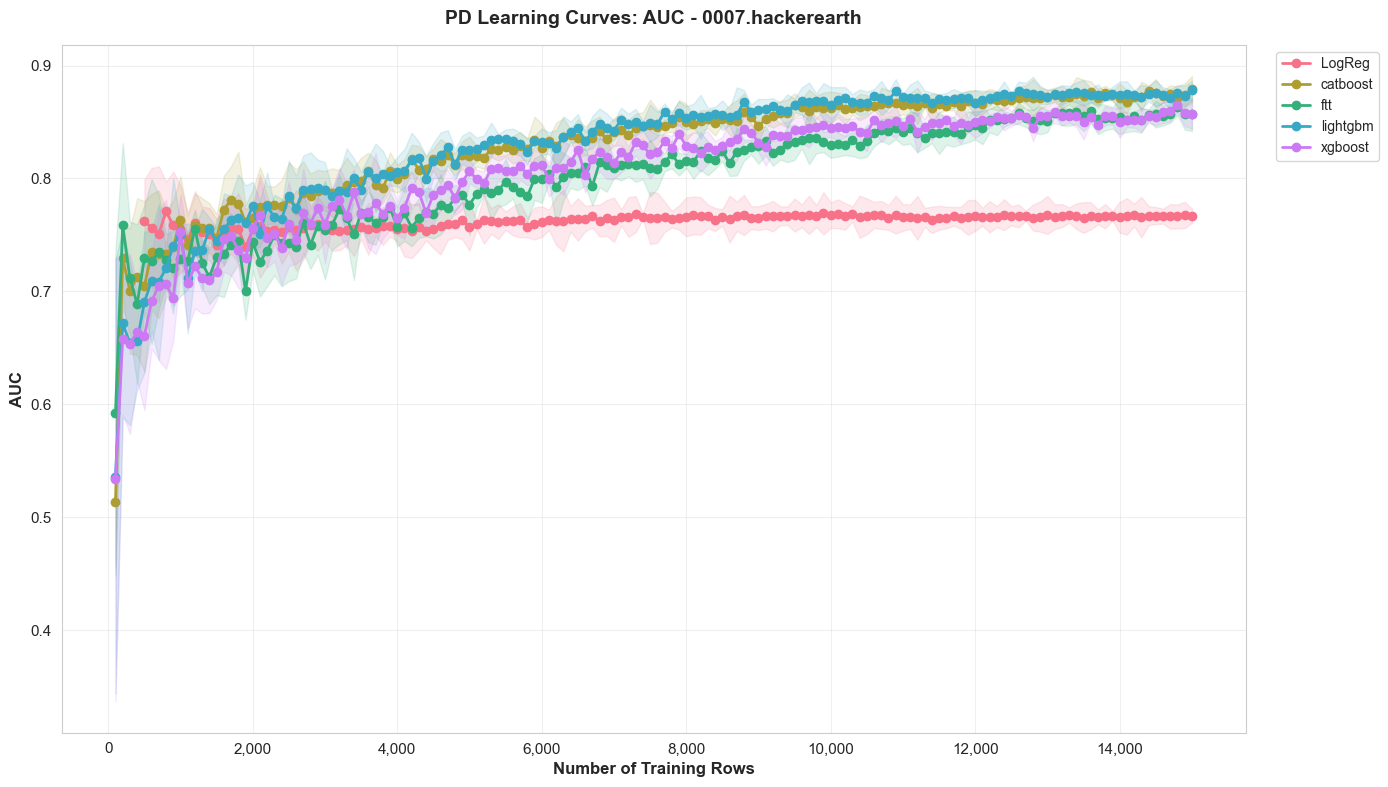

Saved: pd_learning_curve_foundation_auc_0007_hackerearth.png


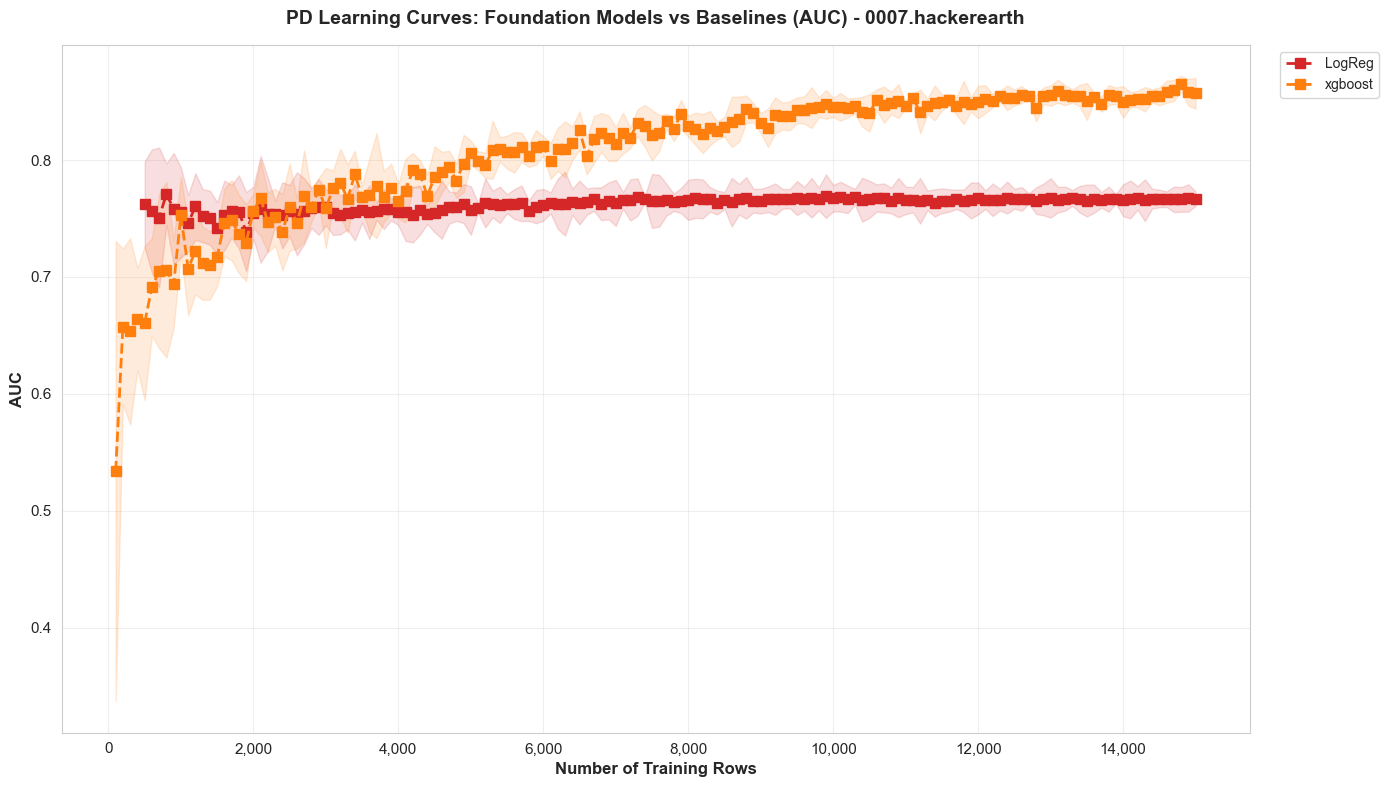


Dataset: 0008.cobranded
Saved: pd_learning_curve_auc_0008_cobranded.png


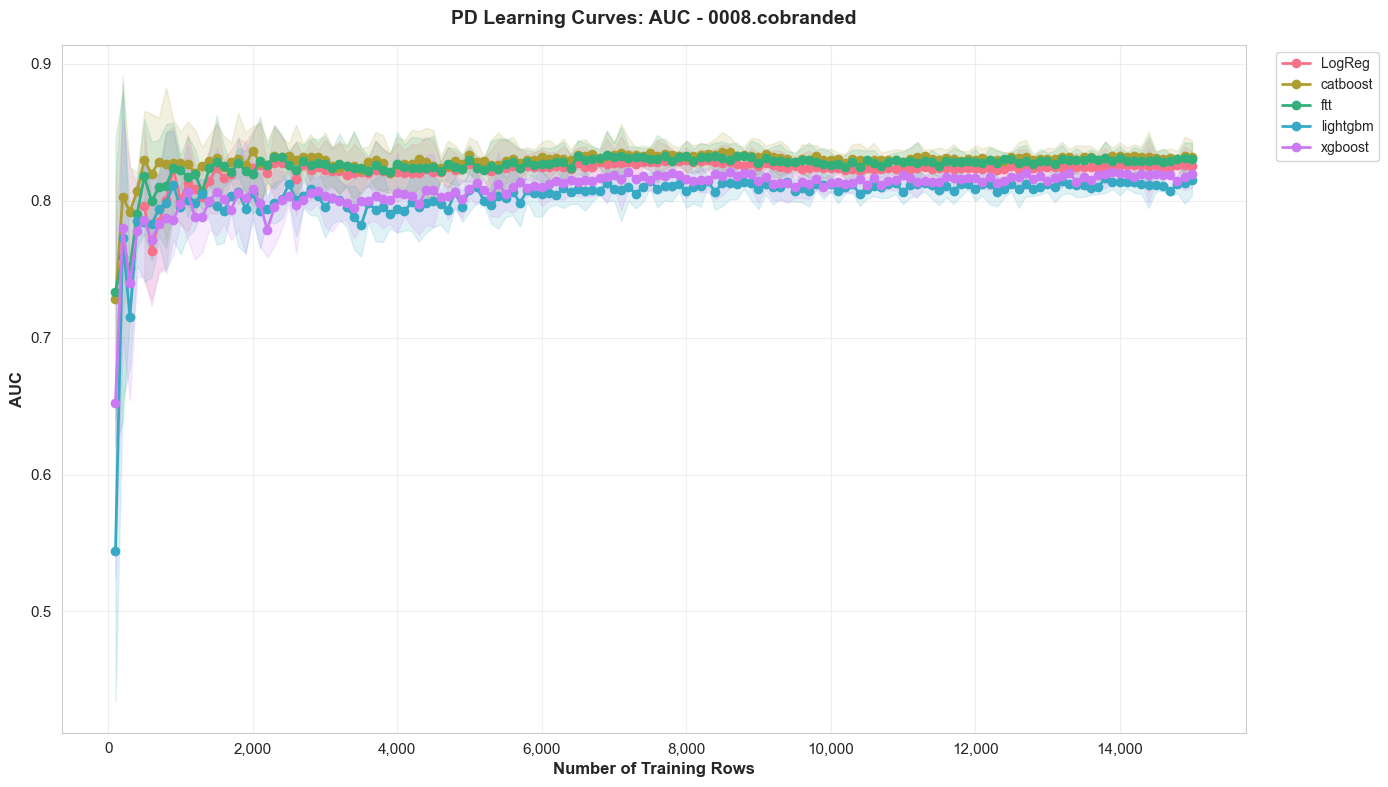

Saved: pd_learning_curve_foundation_auc_0008_cobranded.png


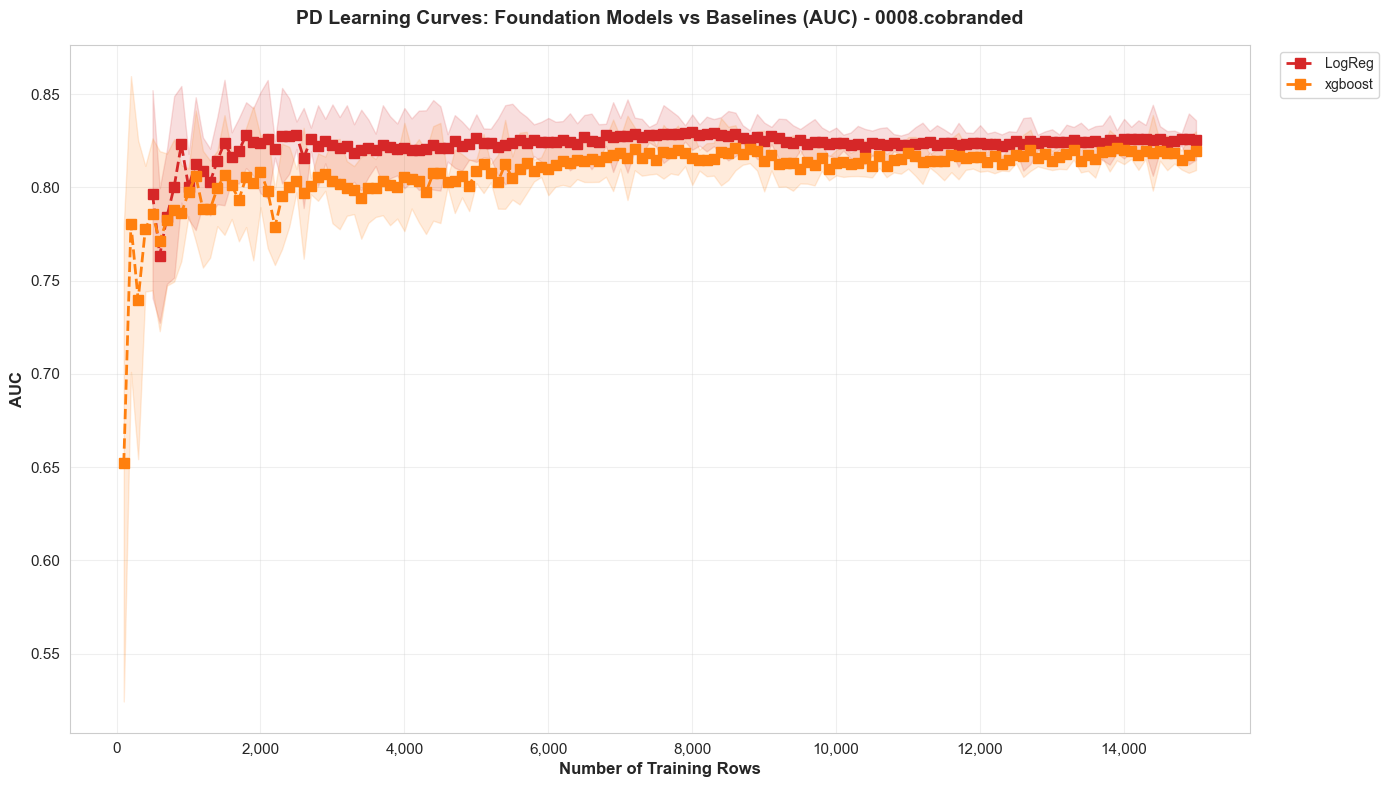


Dataset: 0009.german
Saved: pd_learning_curve_auc_0009_german.png


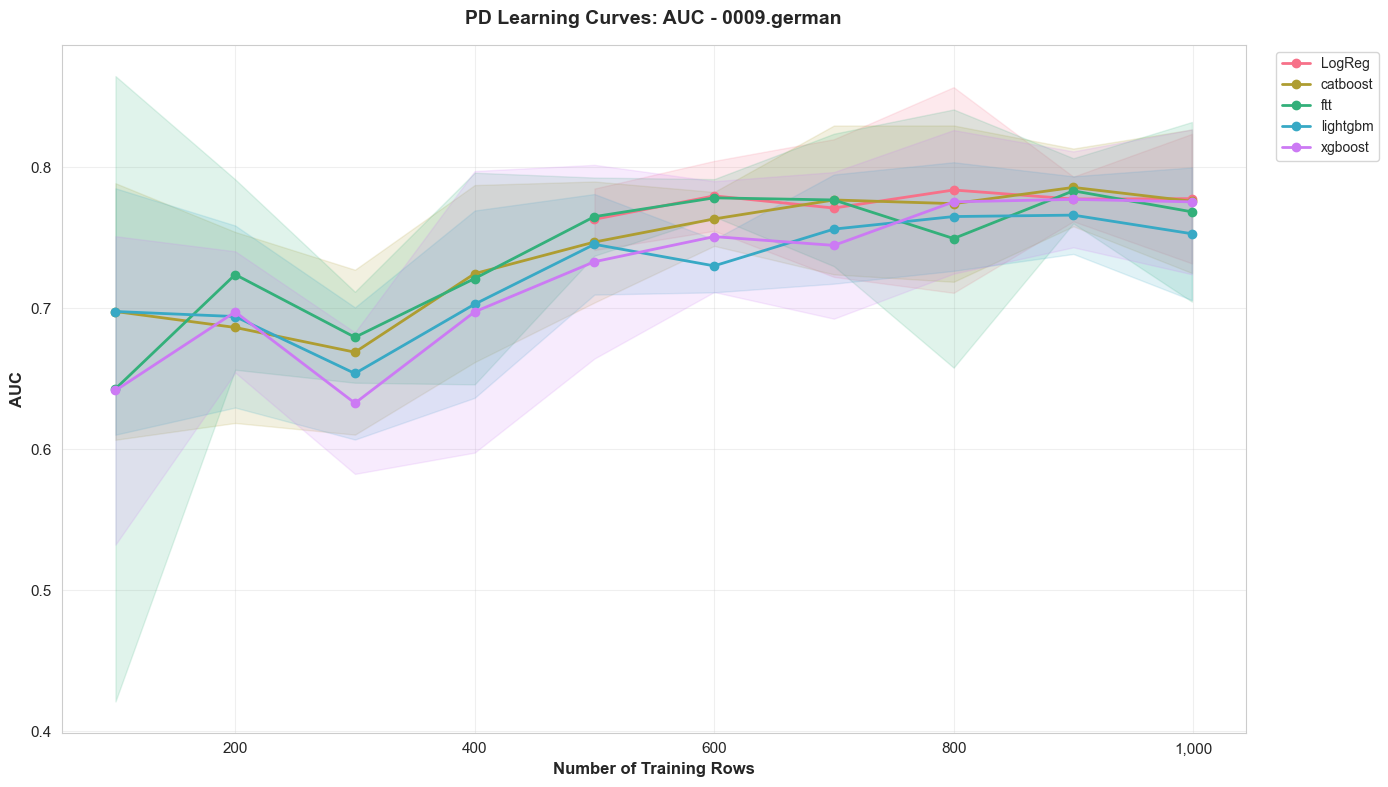

Saved: pd_learning_curve_foundation_auc_0009_german.png


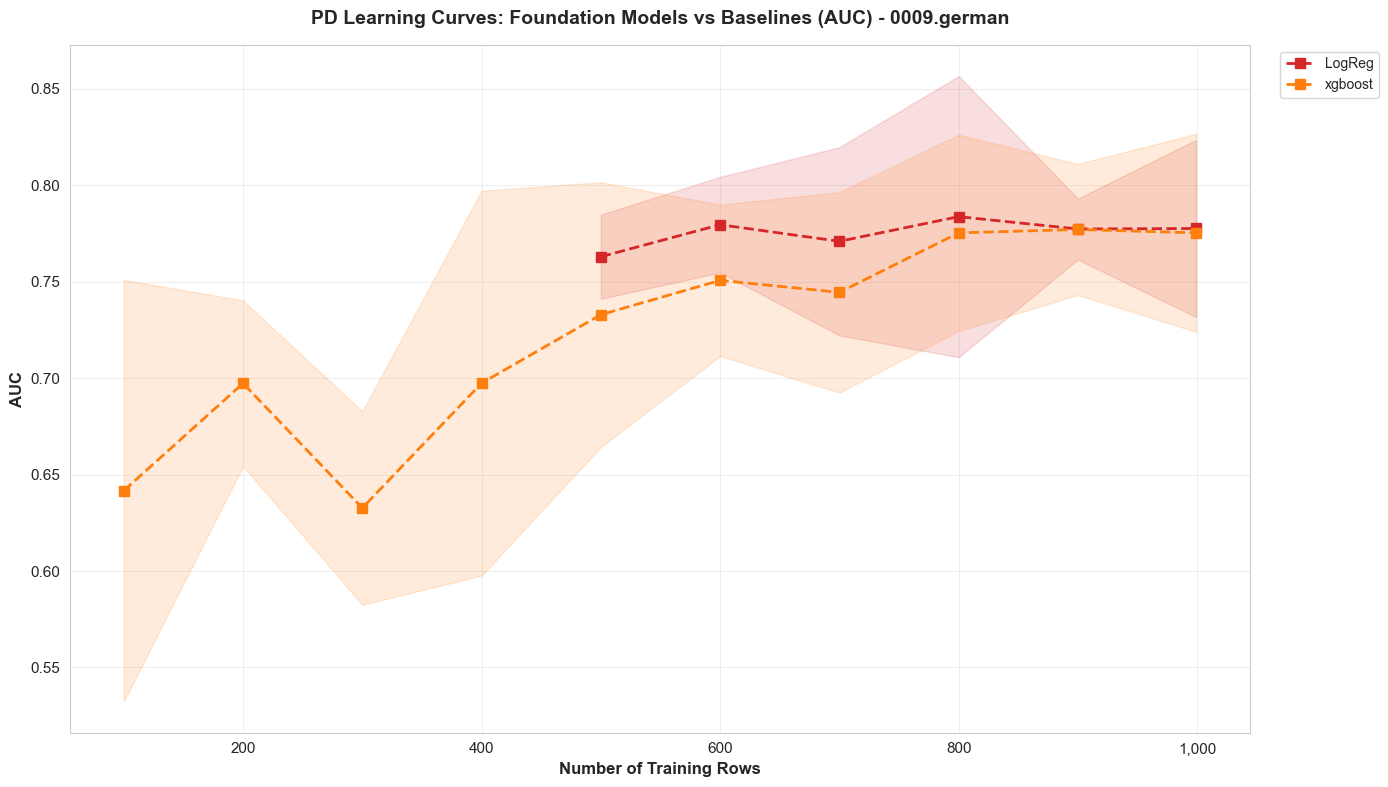


Dataset: 0010.bank_status
Saved: pd_learning_curve_auc_0010_bank_status.png


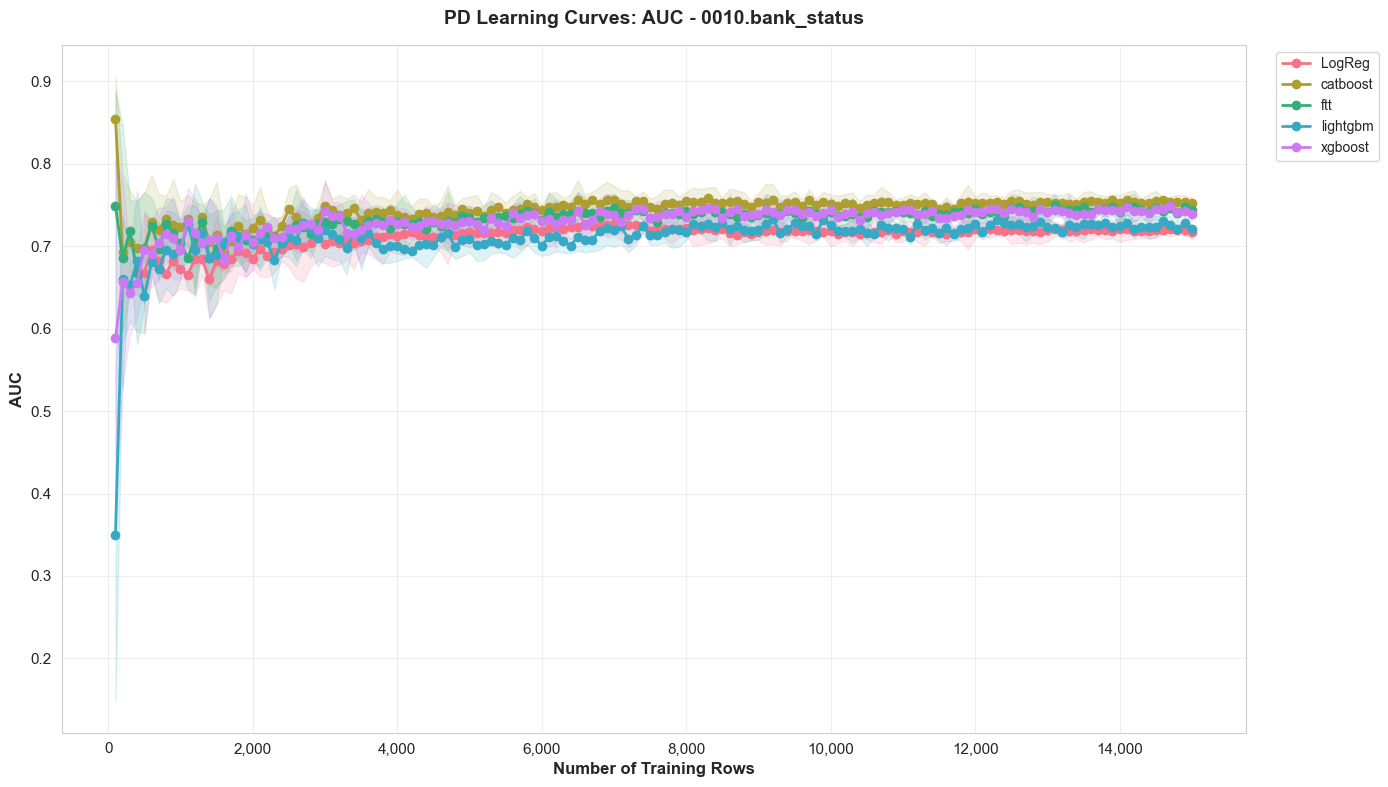

Saved: pd_learning_curve_foundation_auc_0010_bank_status.png


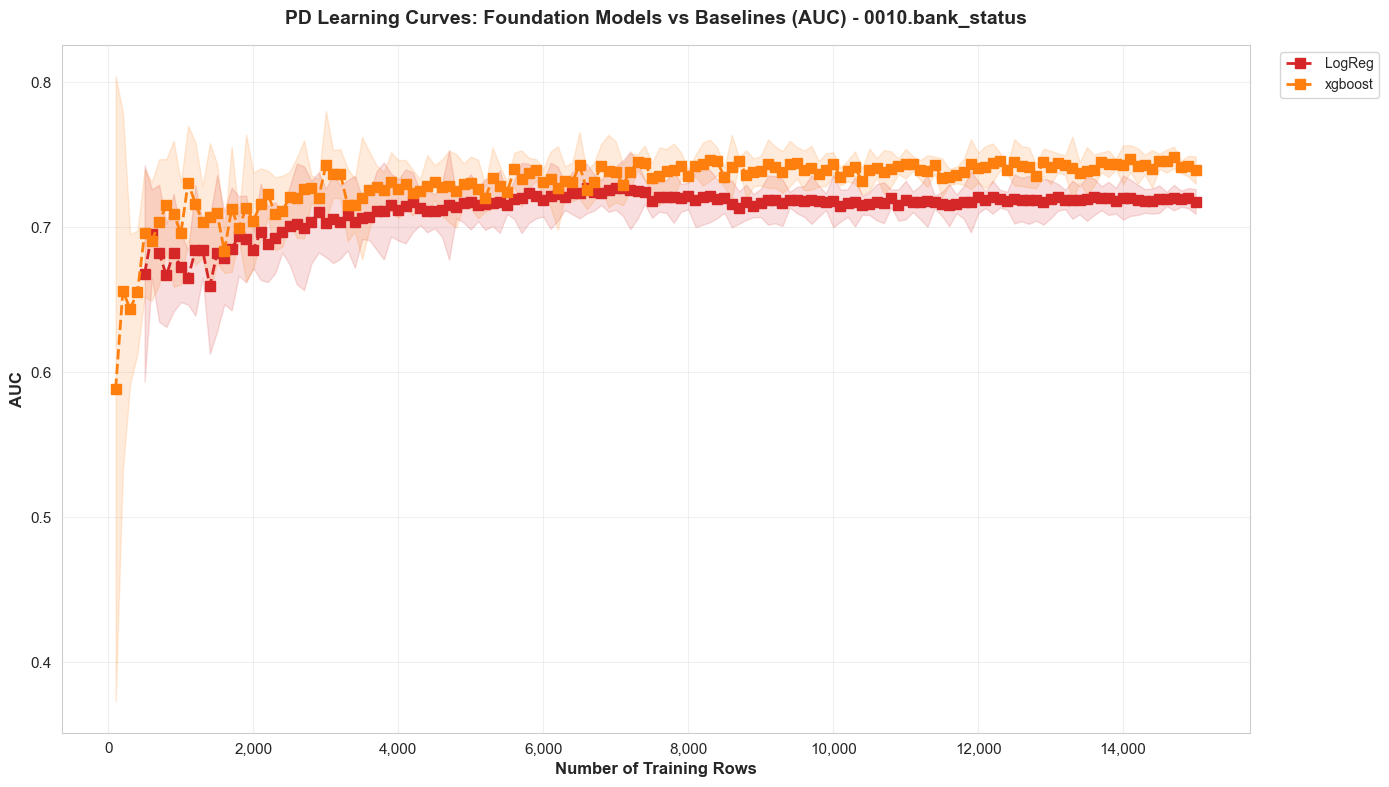


Dataset: 0012.loan_default
Saved: pd_learning_curve_auc_0012_loan_default.png


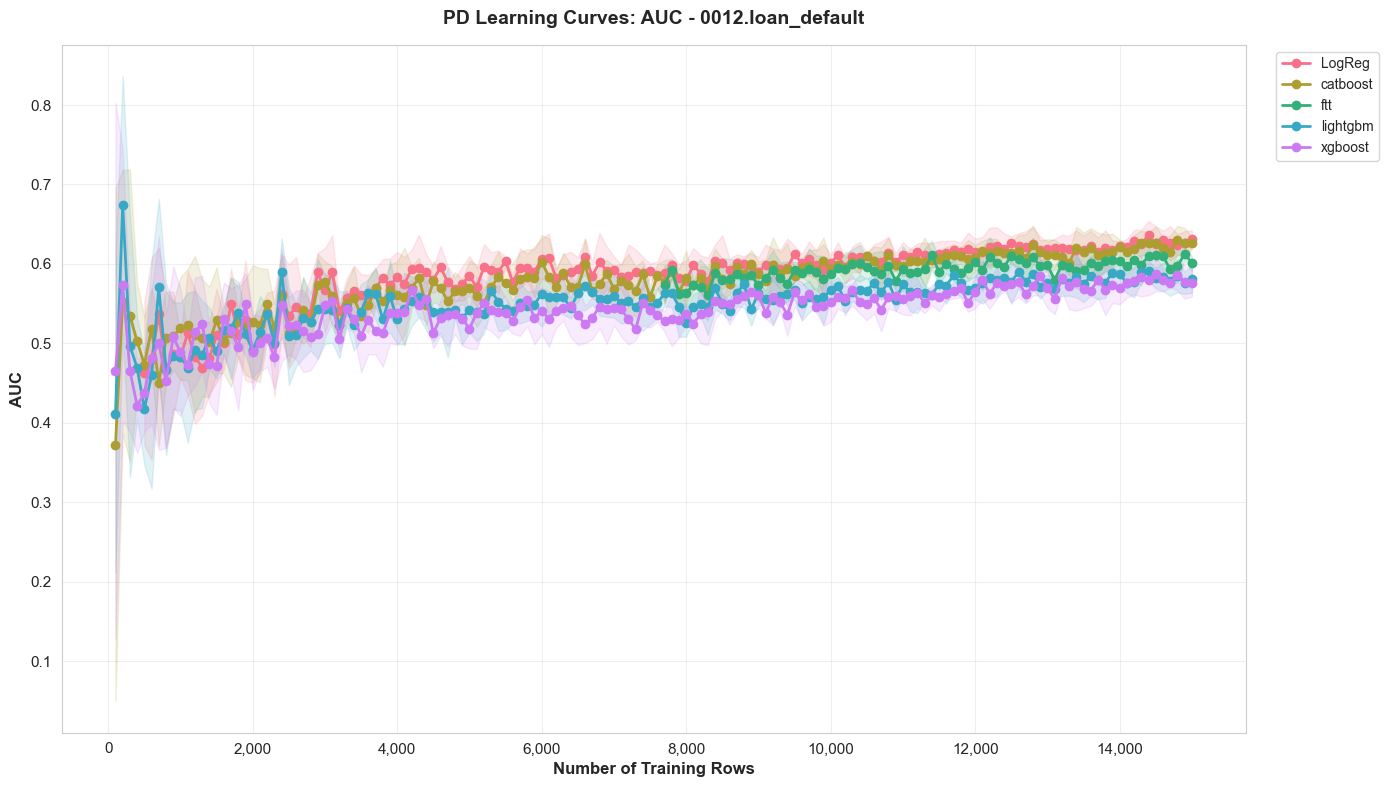

Saved: pd_learning_curve_foundation_auc_0012_loan_default.png


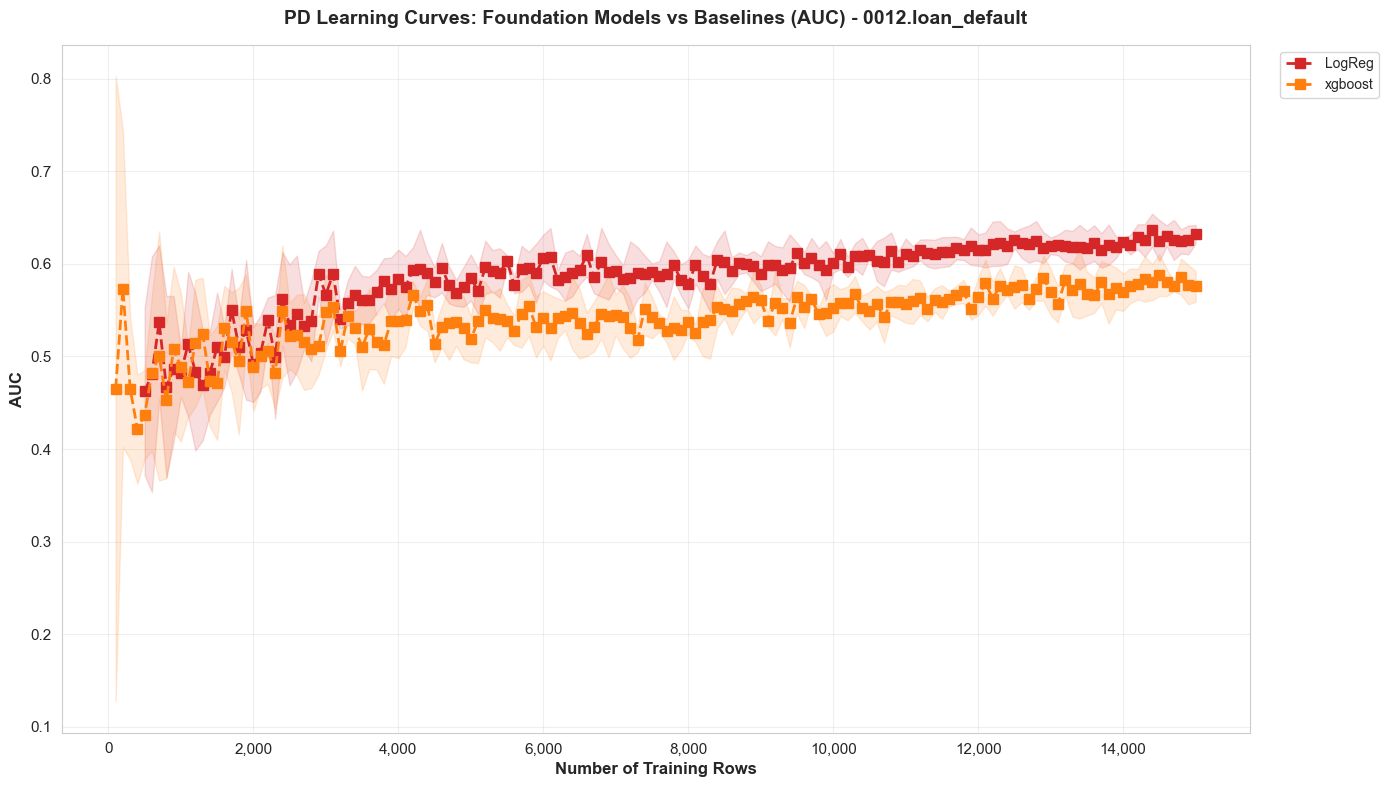


Dataset: 0013.home_credit
Saved: pd_learning_curve_auc_0013_home_credit.png


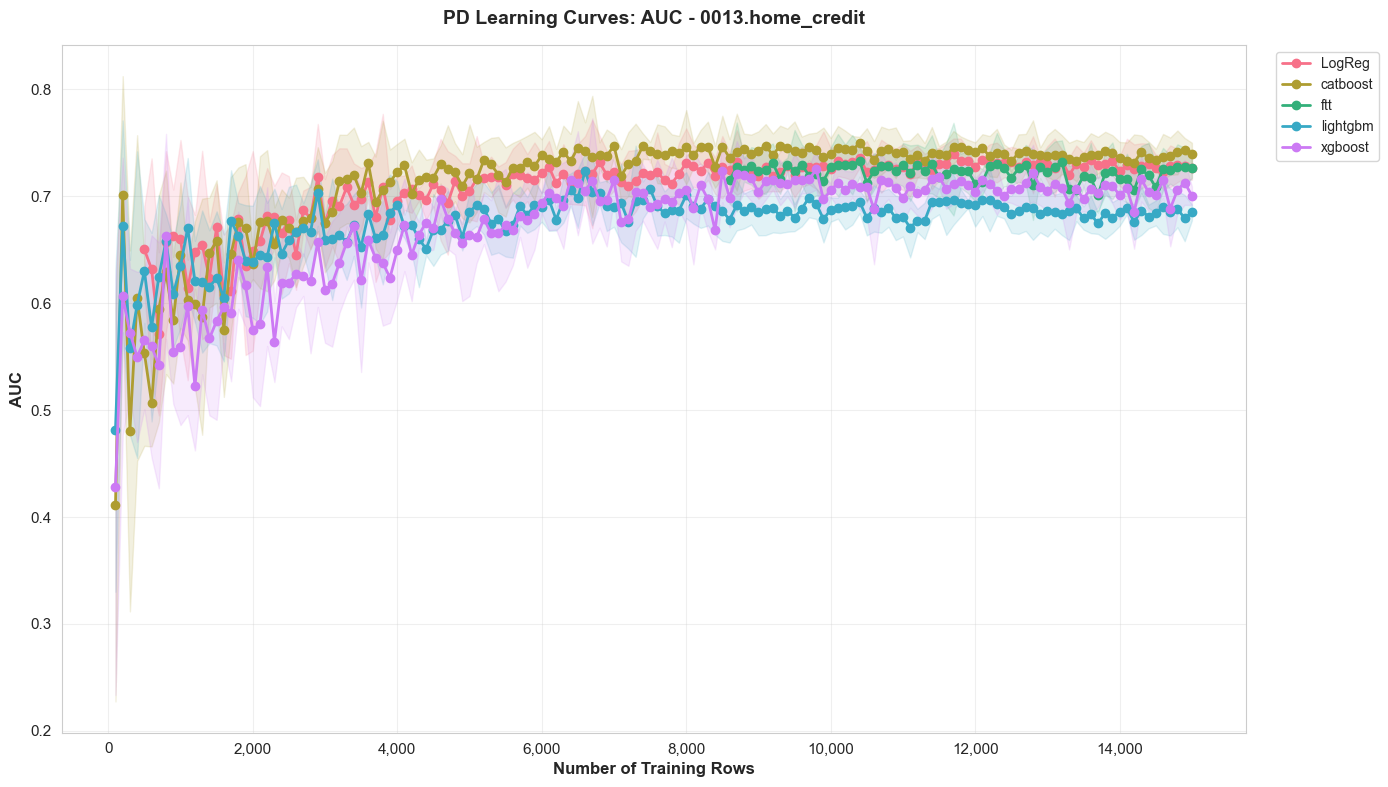

Saved: pd_learning_curve_foundation_auc_0013_home_credit.png


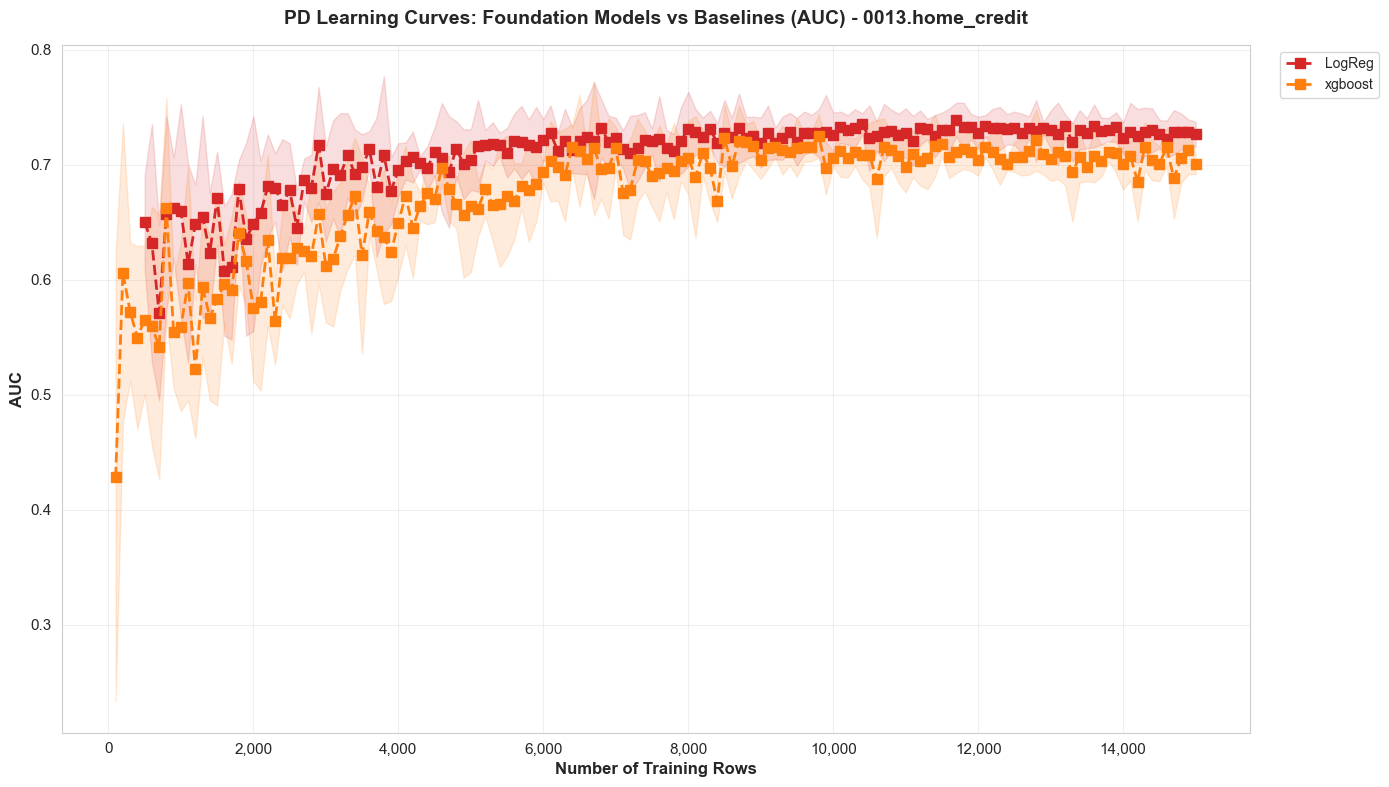


Dataset: 0015.algorithmwatch
Saved: pd_learning_curve_auc_0015_algorithmwatch.png


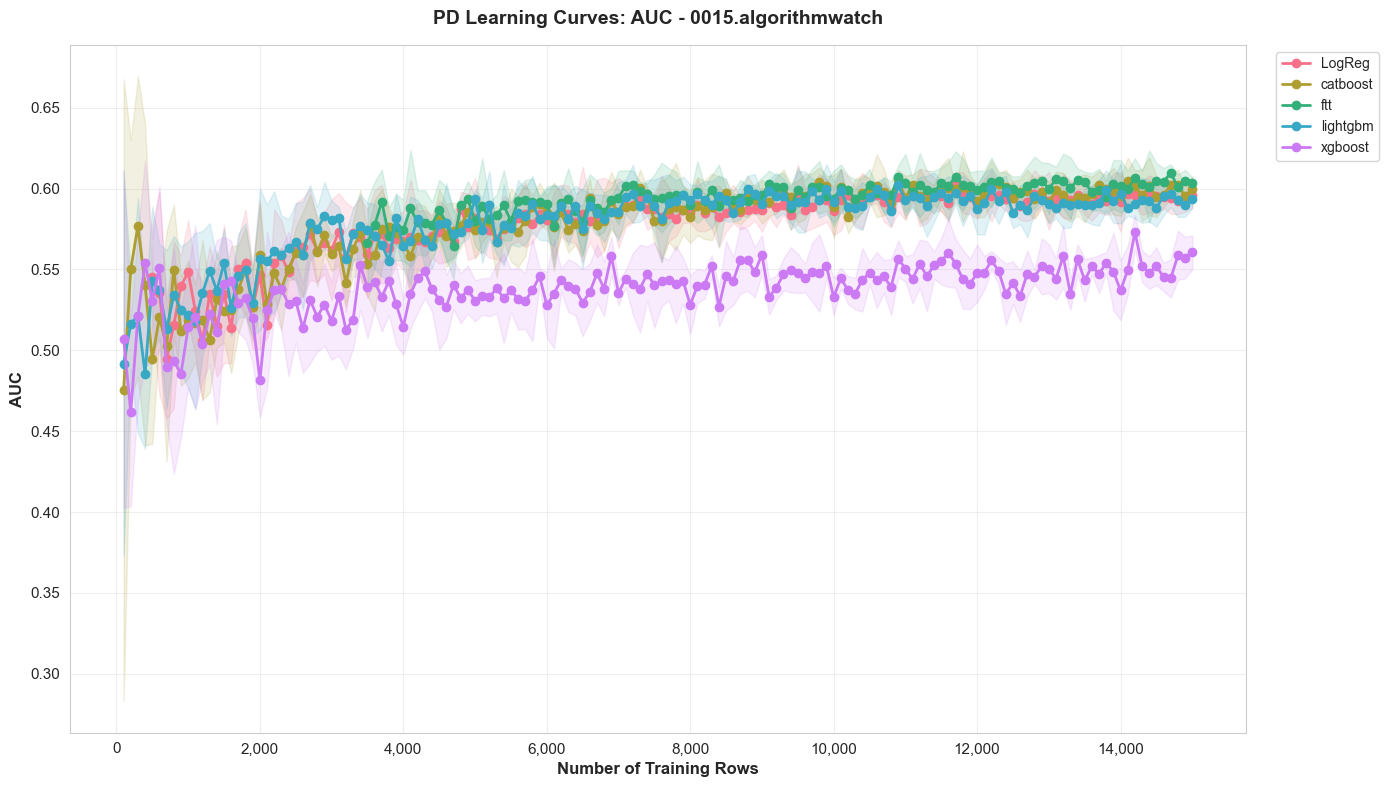

Saved: pd_learning_curve_foundation_auc_0015_algorithmwatch.png


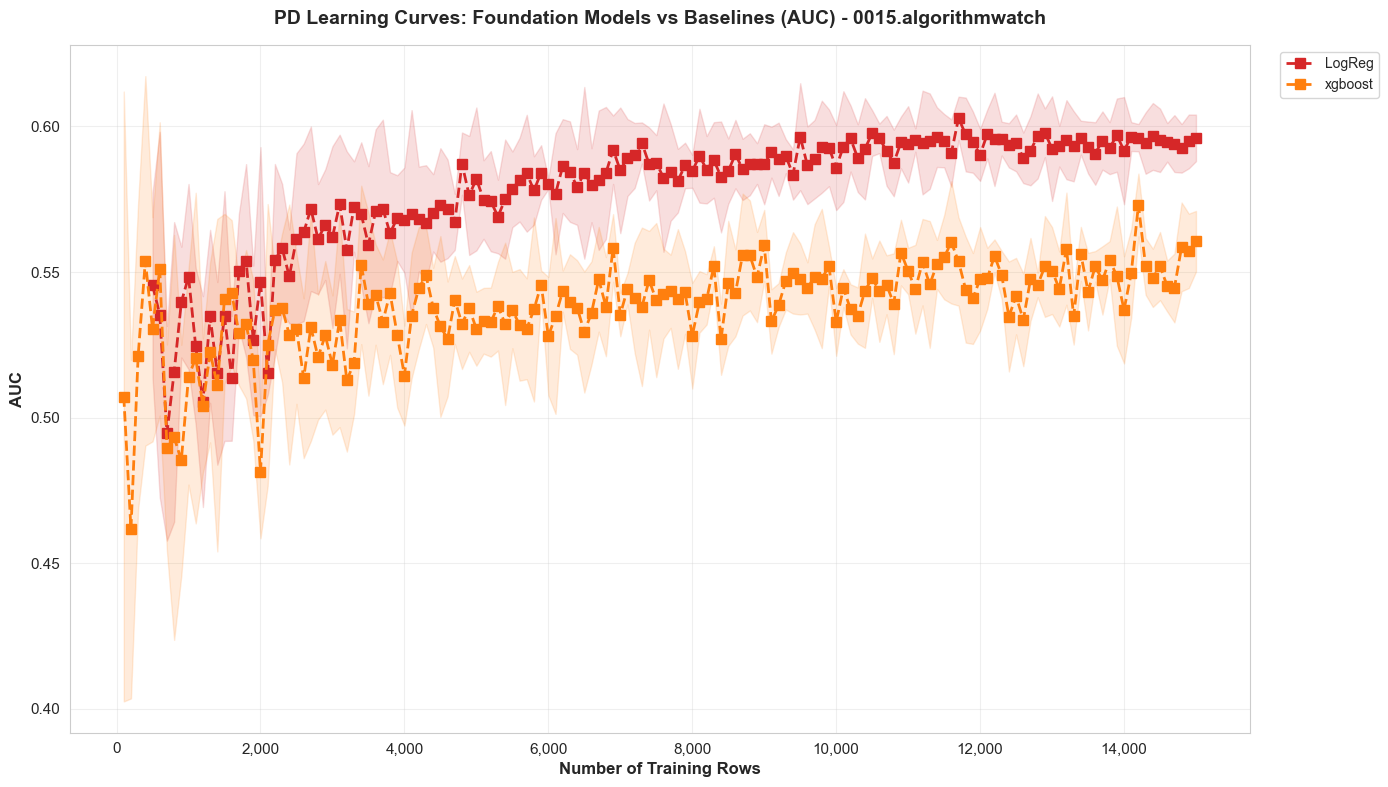

In [18]:
if has_pd and not pd_agg.empty:
    # ==========================================================================
    # A3.1 Foundation Models vs Baselines (Averaged)
    # ==========================================================================
    print("\n" + "=" * 80)
    print("  FOUNDATION MODELS vs BASELINES (Averaged Across Datasets)")
    print("=" * 80)
    plot_learning_curves_foundation_focus(pd_agg, 'AUC', 'PD')
    plt.show()
    
    # ==========================================================================
    # A3.2 Per-Dataset Learning Curves (ALL Datasets)
    # ==========================================================================
    print("\n" + "=" * 80)
    print("  PER-DATASET LEARNING CURVES")
    print("=" * 80)
    
    datasets = sorted(pd_agg['dataset'].unique())
    print(f"\nGenerating learning curves for {len(datasets)} datasets...")
    
    for dataset in datasets:
        print(f"\n{'='*60}")
        print(f"Dataset: {dataset}")
        print(f"{'='*60}")
        
        # All methods
        plot_learning_curves(pd_agg, 'AUC', 'PD', dataset=dataset)
        plt.show()
        
        # Foundation focus
        plot_learning_curves_foundation_focus(pd_agg, 'AUC', 'PD', dataset=dataset)
        plt.show()

---

# Part B: LGD (Loss Given Default) Analysis

---

## B1. Learning Curve Visualizations

### B1.1 Overall Learning Curves (R2)

Creating LGD R2 Learning Curves...
Saved: lgd_learning_curve_r2.png


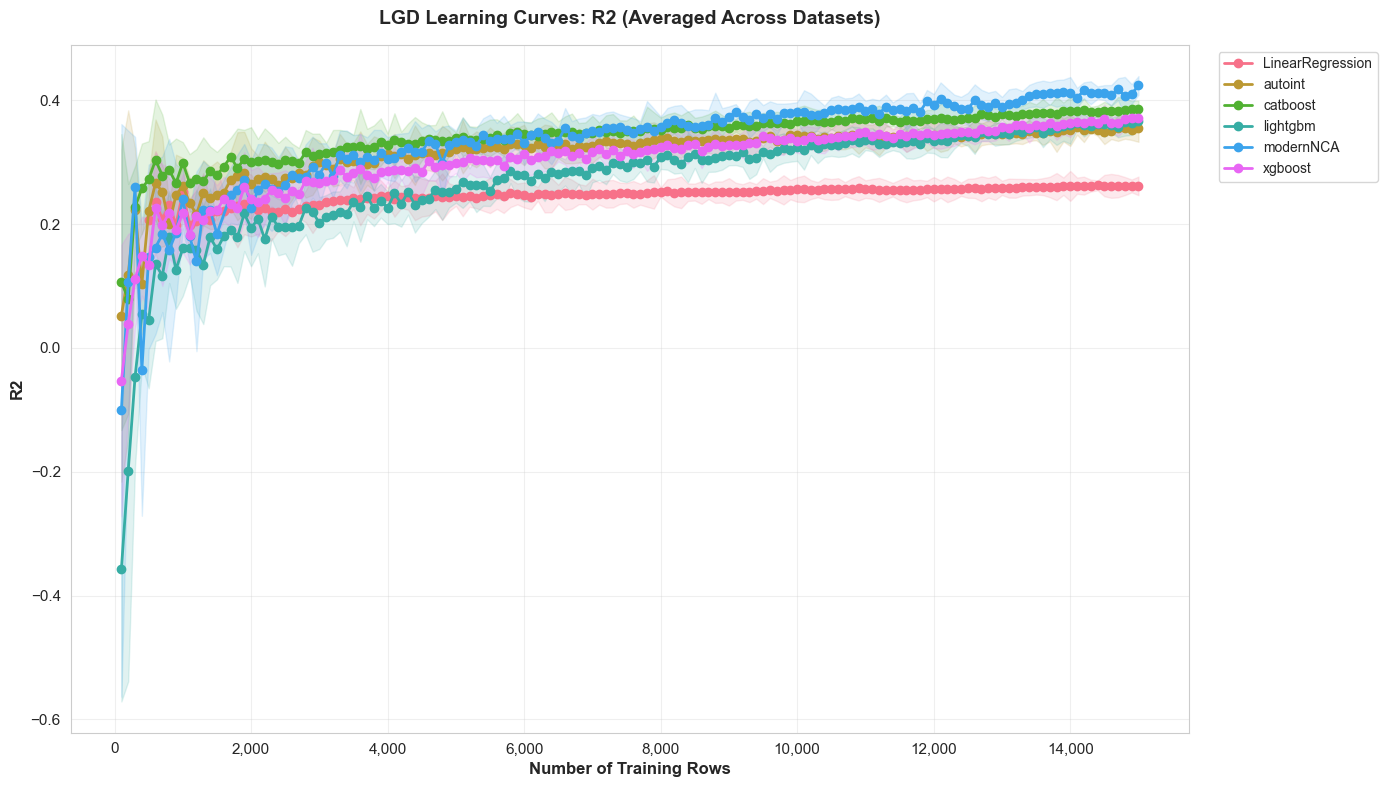

In [19]:
if has_lgd and not lgd_agg.empty:
    print("Creating LGD R2 Learning Curves...")
    plot_learning_curves(lgd_agg, 'R2', 'LGD')
    plt.show()
else:
    print("No LGD data available")

### B1.2 Relative Performance Decay

Creating LGD Relative Performance Decay...
Saved: lgd_relative_performance_r2.png


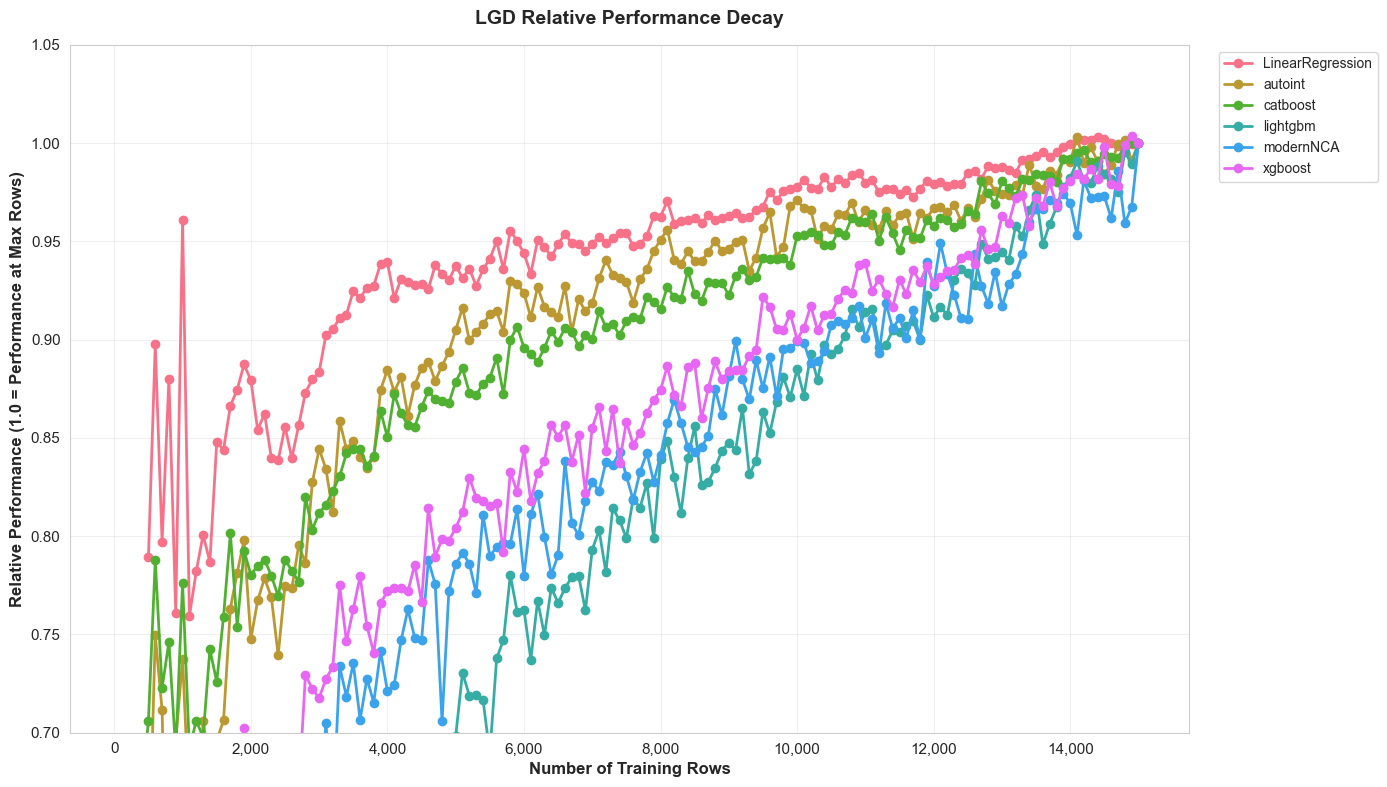

In [20]:
if has_lgd and not lgd_agg.empty:
    print("Creating LGD Relative Performance Decay...")
    plot_relative_performance(lgd_agg, 'R2', 'LGD')
    plt.show()

## B2. Degradation Analysis

**How cross-validation (CV) is used:**
- Each dataset-method-row_limit combination is evaluated using K-fold CV
- Results are averaged across folds to produce mean and std for each metric
- This ensures stable performance estimates despite randomness in data splits

### B2.1 Degradation Metrics Table

In [21]:
if has_lgd and not lgd_agg.empty:
    lgd_degradation = calculate_degradation(lgd_agg, 'R2', 'LGD')
    
    print("\n" + "=" * 80)
    print("  LGD DEGRADATION ANALYSIS (R2)")
    print("=" * 80)
    print("\nMethods sorted by performance at maximum row limit:")
    display(lgd_degradation.round(4))
    
    print("\n" + "-" * 40)
    print("Most ROBUST methods (lowest % drop):")
    print("-" * 40)
    print(lgd_degradation.nsmallest(5, 'pct_drop')[['method', 'R2_at_max', 'R2_at_min', 'pct_drop']].to_string(index=False))
    
    print("\n" + "-" * 40)
    print("LEAST robust methods (highest % drop):")
    print("-" * 40)
    print(lgd_degradation.nlargest(5, 'pct_drop')[['method', 'R2_at_max', 'R2_at_min', 'pct_drop']].to_string(index=False))


  LGD DEGRADATION ANALYSIS (R2)

Methods sorted by performance at maximum row limit:


,method,R2_at_max,R2_at_min,row_max,row_min,abs_drop,pct_drop,degradation_rate_per_1k
4,modernNCA,0.4240,-0.1008,15000,100,0.5248,123.7761,0.0352
2,catboost,0.3853,0.1064,15000,100,0.2790,72.3938,0.0187
5,xgboost,0.3707,-0.0526,15000,100,0.4233,114.1992,0.0284
3,lightgbm,0.3668,-0.3577,15000,100,0.7245,197.5309,0.0486
1,autoint,0.3549,0.0523,15000,100,0.3026,85.2582,0.0203
0,LinearRegression,0.2618,0.2067,15000,500,0.0551,21.0552,0.0038



----------------------------------------
Most ROBUST methods (lowest % drop):
----------------------------------------
          method  R2_at_max  R2_at_min   pct_drop
LinearRegression   0.261786   0.206666  21.055215
        catboost   0.385331   0.106375  72.393828
         autoint   0.354910   0.052320  85.258234
         xgboost   0.370658  -0.052631 114.199208
       modernNCA   0.423978  -0.100805 123.776116

----------------------------------------
LEAST robust methods (highest % drop):
----------------------------------------
   method  R2_at_max  R2_at_min   pct_drop
 lightgbm   0.366767  -0.357711 197.530857
modernNCA   0.423978  -0.100805 123.776116
  xgboost   0.370658  -0.052631 114.199208
  autoint   0.354910   0.052320  85.258234
 catboost   0.385331   0.106375  72.393828


### B2.2 Degradation Visualization

Creating LGD Degradation Analysis Plots...
Saved: lgd_degradation_r2.png


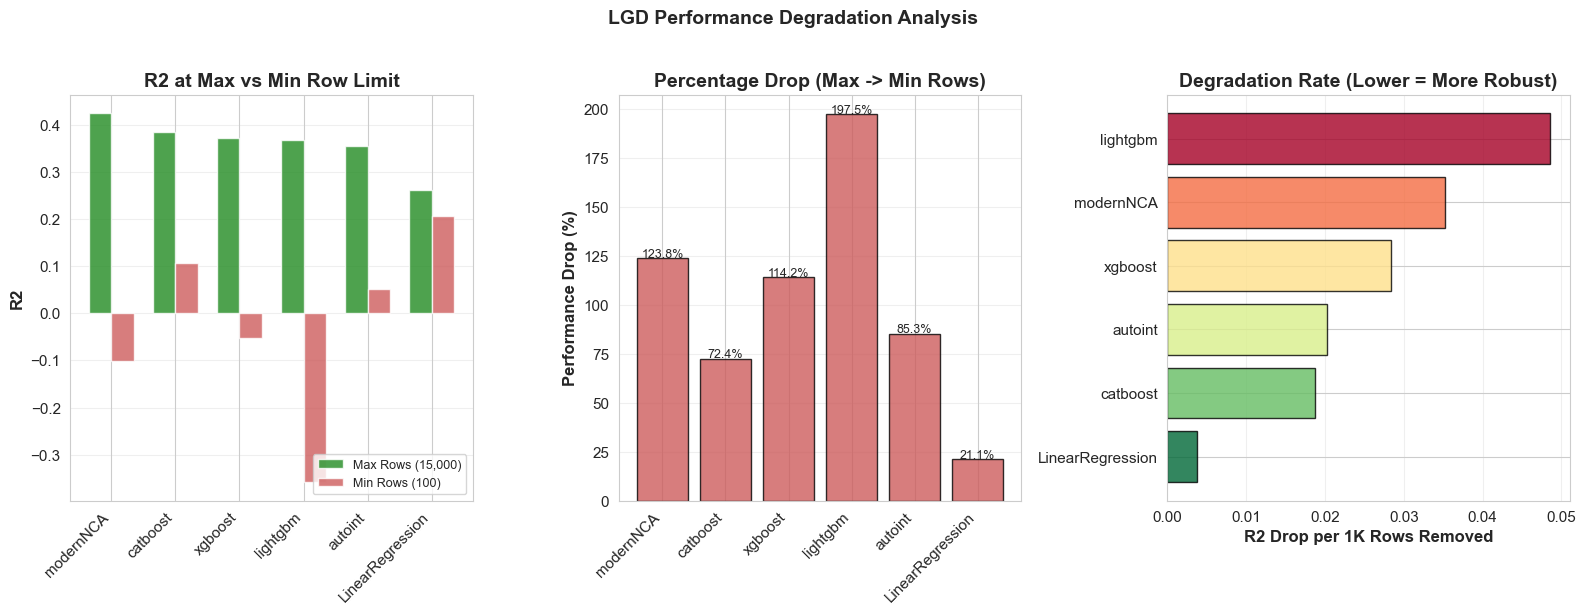

In [22]:
if has_lgd and not lgd_agg.empty:
    print("Creating LGD Degradation Analysis Plots...")
    plot_degradation_analysis(lgd_degradation, 'R2', 'LGD')
    plt.show()

### B2.3 Robustness vs Performance Scatter

Creating LGD Robustness vs Performance Scatter...
Saved: lgd_robustness_scatter_r2.png


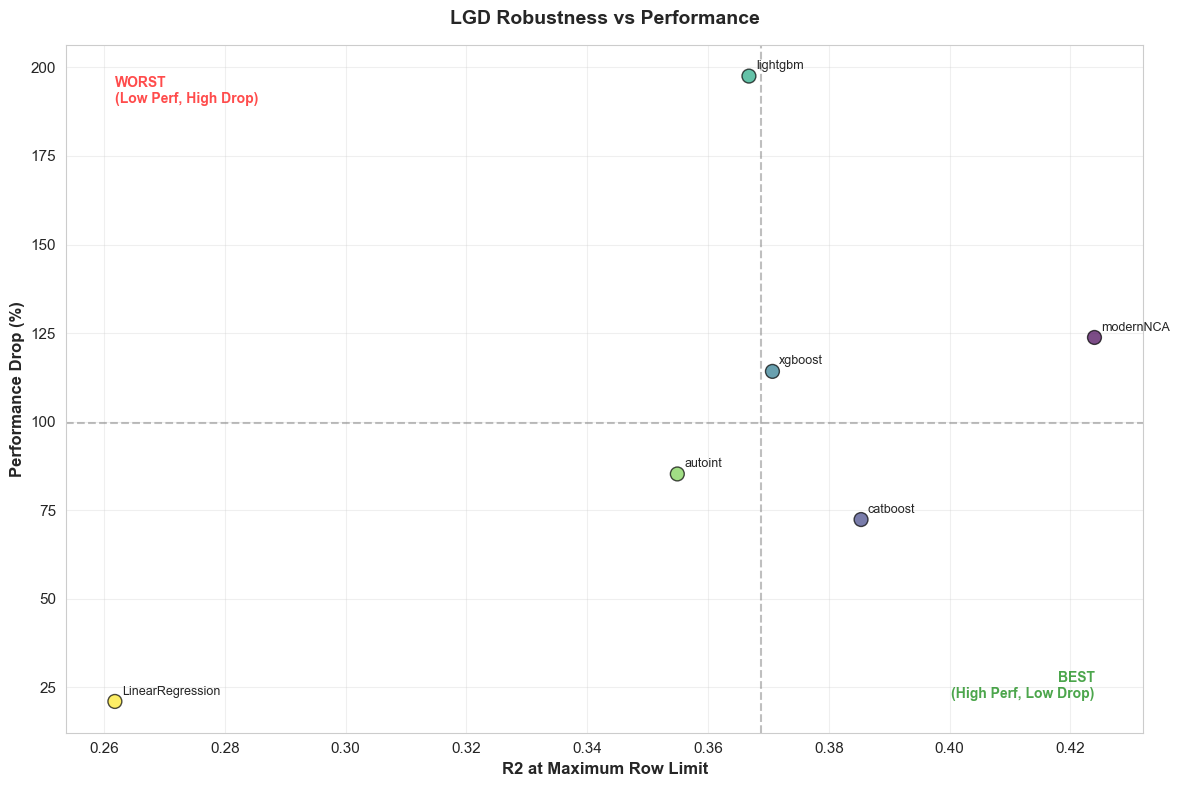

In [23]:
if has_lgd and not lgd_agg.empty:
    print("Creating LGD Robustness vs Performance Scatter...")
    plot_robustness_ranking(lgd_agg, 'R2', 'LGD')
    plt.show()

In [24]:
<cell_type>markdown</cell_type>## B3. Per-Dataset Analysis (LGD)

SyntaxError: invalid syntax (332404290.py, line 1)

In [ ]:
if has_lgd and not lgd_agg.empty:
    # ==========================================================================
    # B3.1 Foundation Models vs Baselines (Averaged)
    # ==========================================================================
    print("\n" + "=" * 80)
    print("  FOUNDATION MODELS vs BASELINES - LGD (Averaged Across Datasets)")
    print("=" * 80)
    plot_learning_curves_foundation_focus(lgd_agg, 'R2', 'LGD')
    plt.show()
    
    # ==========================================================================
    # B3.2 Per-Dataset Learning Curves (ALL Datasets)
    # ==========================================================================
    print("\n" + "=" * 80)
    print("  PER-DATASET LEARNING CURVES (LGD)")
    print("=" * 80)
    
    datasets = sorted(lgd_agg['dataset'].unique())
    print(f"\nGenerating learning curves for {len(datasets)} LGD datasets...")
    
    for dataset in datasets:
        print(f"\n{'='*60}")
        print(f"Dataset: {dataset}")
        print(f"{'='*60}")
        
        # All methods
        plot_learning_curves(lgd_agg, 'R2', 'LGD', dataset=dataset)
        plt.show()
        
        # Foundation focus
        plot_learning_curves_foundation_focus(lgd_agg, 'R2', 'LGD', dataset=dataset)
        plt.show()

---

# Part C: Summary and Recommendations

---

## C1. Method Recommendations by Data Size

In [ ]:
def create_recommendations_table(df, metric, task_name):
    """
    Create a recommendations table showing best methods at different data sizes.
    """
    mean_col = f'{metric}_mean'
    
    if mean_col not in df.columns:
        return None
    
    # Average across datasets
    avg_df = df.groupby(['method', 'row_limit'])[mean_col].mean().reset_index()
    
    # Get unique row limits
    row_limits = sorted(avg_df['row_limit'].unique(), reverse=True)
    
    recommendations = []
    
    for row_limit in row_limits:
        subset = avg_df[avg_df['row_limit'] == row_limit].nlargest(5, mean_col)
        rec = {
            'Row Limit': f"{row_limit:,}",
            '1st': f"{subset.iloc[0]['method']} ({subset.iloc[0][mean_col]:.4f})",
            '2nd': f"{subset.iloc[1]['method']} ({subset.iloc[1][mean_col]:.4f})" if len(subset) > 1 else '-',
            '3rd': f"{subset.iloc[2]['method']} ({subset.iloc[2][mean_col]:.4f})" if len(subset) > 2 else '-',
        }
        recommendations.append(rec)
    
    rec_df = pd.DataFrame(recommendations)
    
    print(f"\n{'='*80}")
    print(f"  {task_name} TOP METHODS BY DATA SIZE ({metric})")
    print(f"{'='*80}")
    display(rec_df)
    
    return rec_df

if has_pd and not pd_agg.empty:
    pd_recommendations = create_recommendations_table(pd_agg, 'AUC', 'PD')

if has_lgd and not lgd_agg.empty:
    lgd_recommendations = create_recommendations_table(lgd_agg, 'R2', 'LGD')

## C2. Final Summary Statistics

In [ ]:
print("\n" + "=" * 80)
print("  EXPERIMENT 2: LEARNING CURVE ANALYSIS SUMMARY")
print("=" * 80)

if has_pd and not pd_agg.empty:
    print(f"\nPD Task:")
    print(f"  - Methods analyzed: {pd_agg['method'].nunique()}")
    print(f"  - Datasets: {pd_agg['dataset'].nunique()}")
    print(f"  - Row limit range: {pd_agg['row_limit'].max():,} -> {pd_agg['row_limit'].min():,}")
    print(f"  - Number of row limit steps: {pd_agg['row_limit'].nunique()}")

if has_lgd and not lgd_agg.empty:
    print(f"\nLGD Task:")
    print(f"  - Methods analyzed: {lgd_agg['method'].nunique()}")
    print(f"  - Datasets: {lgd_agg['dataset'].nunique()}")
    print(f"  - Row limit range: {lgd_agg['row_limit'].max():,} -> {lgd_agg['row_limit'].min():,}")
    print(f"  - Number of row limit steps: {lgd_agg['row_limit'].nunique()}")

print(f"\nFigures saved to: {FIGURES_DIR}")
print("=" * 80)